In [1]:
from pathlib import Path
import duckdb

PROJECT_ROOT = Path("..")

DATA_PATTERN = str(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "network_ml"
    / "encoded_*.parquet"
)

RESULT_DIR = (
    PROJECT_ROOT
    / "results"
    / "preprocessing"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

con = duckdb.connect()

class_dist = con.execute(
    f"""
    SELECT
        Label,
        label_id,
        COUNT(*) AS count
    FROM read_parquet('{DATA_PATTERN}')
    GROUP BY Label, label_id
    ORDER BY count DESC
    """
).fetchdf()

print(class_dist.to_string(index=False))

class_dist.to_csv(
    RESULT_DIR / "class_distribution_after_preprocessing.csv",
    index=False
)

                   Label  label_id    count
                  Benign         0 13484708
        DDOS attack-HOIC         4   686012
  DDoS attacks-LOIC-HTTP         6   576191
        DoS attacks-Hulk         8   461912
                     Bot         1   286191
          FTP-BruteForce        11   193360
          SSH-Bruteforce        14   187589
           Infilteration        12   161934
DoS attacks-SlowHTTPTest         9   139890
   DoS attacks-GoldenEye         7    41508
   DoS attacks-Slowloris        10    10990
    DDOS attack-LOIC-UDP         5     1730
        Brute Force -Web         2      611
        Brute Force -XSS         3      230
           SQL Injection        13       87


In [2]:
source_dist = con.execute(
    f"""
    SELECT
        source_file,
        Label,
        label_id,
        COUNT(*) AS count
    FROM read_parquet('{DATA_PATTERN}')
    GROUP BY
        source_file,
        Label,
        label_id
    ORDER BY
        source_file,
        count DESC
    """
).fetchdf()

print(source_dist.to_string(index=False))

source_dist.to_csv(
    RESULT_DIR / "source_file_class_distribution.csv",
    index=False
)

                                       source_file                    Label  label_id   count
   Friday-02-03-2018_TrafficForML_CICFlowMeter.csv                   Benign         0  762384
   Friday-02-03-2018_TrafficForML_CICFlowMeter.csv                      Bot         1  286191
   Friday-16-02-2018_TrafficForML_CICFlowMeter.csv         DoS attacks-Hulk         8  461912
   Friday-16-02-2018_TrafficForML_CICFlowMeter.csv                   Benign         0  446772
   Friday-16-02-2018_TrafficForML_CICFlowMeter.csv DoS attacks-SlowHTTPTest         9  139890
   Friday-23-02-2018_TrafficForML_CICFlowMeter.csv                   Benign         0 1048009
   Friday-23-02-2018_TrafficForML_CICFlowMeter.csv         Brute Force -Web         2     362
   Friday-23-02-2018_TrafficForML_CICFlowMeter.csv         Brute Force -XSS         3     151
   Friday-23-02-2018_TrafficForML_CICFlowMeter.csv            SQL Injection        13      53
 Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv          

In [3]:
con.close()

In [4]:
from pathlib import Path
import duckdb

PROJECT_ROOT = Path("..")

DATA_PATTERN = str(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "network_ml"
    / "encoded_*.parquet"
)

SPLIT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "network_ml_split"
)

TEMP_DIR = (
    PROJECT_ROOT
    / "data"
    / "duckdb_tmp"
)

SPLIT_DIR.mkdir(parents=True, exist_ok=True)
TEMP_DIR.mkdir(parents=True, exist_ok=True)

con = duckdb.connect()

# 8GB RAM 환경 보호
con.execute("SET memory_limit='3GB'")
con.execute("SET threads=4")
con.execute(f"SET temp_directory='{TEMP_DIR}'")

print(DATA_PATTERN)
print(SPLIT_DIR)

../data/processed/network_ml/encoded_*.parquet
../data/processed/network_ml_split


In [5]:
columns = con.execute(
    f"""
    DESCRIBE
    SELECT *
    FROM read_parquet('{DATA_PATTERN}')
    """
).fetchdf()["column_name"].tolist()

MODEL_EXCLUDE_COLUMNS = [
    "Label",
    "label_id",
    "source_file",
    "Timestamp",
    "hour",
    "day_of_week",
]

feature_columns = [
    col
    for col in columns
    if col not in MODEL_EXCLUDE_COLUMNS
]

print("전체 컬럼:", len(columns))
print("모델 Feature:", len(feature_columns))

전체 컬럼: 84
모델 Feature: 78


In [6]:
hash_columns = feature_columns + ["label_id"]

hash_expression = ", ".join(
    f'"{col}"'
    for col in hash_columns
)

print("Hash 대상 Feature:", len(hash_columns))

Hash 대상 Feature: 79


In [7]:
split_check = con.execute(
    f"""
    WITH split_data AS (
        SELECT
            Label,
            label_id,

            hash({hash_expression}) % 100
                AS split_bucket

        FROM read_parquet('{DATA_PATTERN}')
    )

    SELECT
        Label,
        label_id,

        CASE
            WHEN split_bucket < 70 THEN 'train'
            WHEN split_bucket < 85 THEN 'valid'
            ELSE 'test'
        END AS split,

        COUNT(*) AS count

    FROM split_data

    GROUP BY
        Label,
        label_id,
        split

    ORDER BY
        label_id,
        split
    """
).fetchdf()

print(split_check.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                   Label  label_id split   count
                  Benign         0  test 2036116
                  Benign         0 train 9422669
                  Benign         0 valid 2025923
                     Bot         1  test   47767
                     Bot         1 train  200472
                     Bot         1 valid   37952
        Brute Force -Web         2  test      94
        Brute Force -Web         2 train     438
        Brute Force -Web         2 valid      79
        Brute Force -XSS         3  test      26
        Brute Force -XSS         3 train     164
        Brute Force -XSS         3 valid      40
        DDOS attack-HOIC         4  test  102873
        DDOS attack-HOIC         4 train  479200
        DDOS attack-HOIC         4 valid  103939
    DDOS attack-LOIC-UDP         5  test     264
    DDOS attack-LOIC-UDP         5 train    1206
    DDOS attack-LOIC-UDP         5 valid     260
  DDoS attacks-LOIC-HTTP         6  test   86343
  DDoS attacks-LOIC-

In [8]:
pivot = split_check.pivot_table(
    index=["Label", "label_id"],
    columns="split",
    values="count",
    fill_value=0
)

for col in ["train", "valid", "test"]:
    if col not in pivot.columns:
        pivot[col] = 0

pivot = pivot[
    ["train", "valid", "test"]
]

pivot["total"] = (
    pivot["train"]
    + pivot["valid"]
    + pivot["test"]
)

pivot["train_ratio"] = (
    pivot["train"]
    / pivot["total"]
)

pivot["valid_ratio"] = (
    pivot["valid"]
    / pivot["total"]
)

pivot["test_ratio"] = (
    pivot["test"]
    / pivot["total"]
)

print(pivot.to_string())

split                                  train      valid       test       total  train_ratio  valid_ratio  test_ratio
Label                    label_id                                                                                   
Benign                   0         9422669.0  2025923.0  2036116.0  13484708.0     0.698767     0.150239    0.150994
Bot                      1          200472.0    37952.0    47767.0    286191.0     0.700483     0.132611    0.166906
Brute Force -Web         2             438.0       79.0       94.0       611.0     0.716858     0.129296    0.153846
Brute Force -XSS         3             164.0       40.0       26.0       230.0     0.713043     0.173913    0.113043
DDOS attack-HOIC         4          479200.0   103939.0   102873.0    686012.0     0.698530     0.151512    0.149958
DDOS attack-LOIC-UDP     5            1206.0      260.0      264.0      1730.0     0.697110     0.150289    0.152601
DDoS attacks-LOIC-HTTP   6          403195.0    86653.0    86343

In [9]:
problems = pivot[
    (pivot["train"] == 0)
    | (pivot["valid"] == 0)
    | (pivot["test"] == 0)
]

if len(problems) == 0:
    print("모든 클래스가 Train / Valid / Test에 존재합니다.")
else:
    print("주의: Split이 비어 있는 클래스가 있습니다.")
    print(problems.to_string())

모든 클래스가 Train / Valid / Test에 존재합니다.


In [10]:
for name in ["train.parquet", "valid.parquet", "test.parquet"]:
    path = SPLIT_DIR / name
    if path.exists():
        path.unlink()

In [11]:
split_conditions = {
    "train": "split_bucket < 70",
    "valid": "split_bucket >= 70 AND split_bucket < 85",
    "test":  "split_bucket >= 85",
}

for split_name, condition in split_conditions.items():

    output_path = SPLIT_DIR / f"{split_name}.parquet"

    print(f"[START] {split_name}")

    con.execute(
        f"""
        COPY (
            SELECT * EXCLUDE (split_bucket)
            FROM (
                SELECT
                    *,
                    hash({hash_expression}) % 100 AS split_bucket
                FROM read_parquet('{DATA_PATTERN}')
            )
            WHERE {condition}
        )
        TO '{output_path}'
        (
            FORMAT PARQUET,
            COMPRESSION ZSTD
        )
        """
    )

    print(f"[DONE] {output_path}")

[START] train


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[DONE] ../data/processed/network_ml_split/train.parquet
[START] valid


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[DONE] ../data/processed/network_ml_split/valid.parquet
[START] test


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[DONE] ../data/processed/network_ml_split/test.parquet


In [12]:
for name in ["train", "valid", "test"]:
    path = SPLIT_DIR / f"{name}.parquet"

    size_gb = path.stat().st_size / (1024 ** 3)

    print(
        f"{name:5s}: "
        f"{size_gb:.2f} GB"
    )

train: 1.03 GB
valid: 0.23 GB
test : 0.23 GB


In [13]:
split_counts = {}

for name in ["train", "valid", "test"]:

    path = SPLIT_DIR / f"{name}.parquet"

    count = con.execute(
        f"""
        SELECT COUNT(*)
        FROM read_parquet('{path}')
        """
    ).fetchone()[0]

    split_counts[name] = count

    print(
        f"{name:5s}: "
        f"{count:,}"
    )

print("-" * 30)

total = sum(split_counts.values())

print(
    "TOTAL:",
    f"{total:,}"
)

train: 11,325,151
valid: 2,510,951
test : 2,396,841
------------------------------
TOTAL: 16,232,943


In [14]:
for name in ["train", "valid", "test"]:

    path = SPLIT_DIR / f"{name}.parquet"

    print(f"\n===== {name.upper()} =====")

    result = con.execute(
        f"""
        SELECT
            Label,
            label_id,
            COUNT(*) AS count
        FROM read_parquet('{path}')
        GROUP BY Label, label_id
        ORDER BY label_id
        """
    ).fetchdf()

    print(result.to_string(index=False))


===== TRAIN =====
                   Label  label_id   count
                  Benign         0 9422669
                     Bot         1  200472
        Brute Force -Web         2     438
        Brute Force -XSS         3     164
        DDOS attack-HOIC         4  479200
    DDOS attack-LOIC-UDP         5    1206
  DDoS attacks-LOIC-HTTP         6  403195
   DoS attacks-GoldenEye         7   29130
        DoS attacks-Hulk         8  325451
DoS attacks-SlowHTTPTest         9  130947
   DoS attacks-Slowloris        10    7894
          FTP-BruteForce        11  103680
           Infilteration        12  113477
           SQL Injection        13      62
          SSH-Bruteforce        14  107166

===== VALID =====
                   Label  label_id   count
                  Benign         0 2025923
                     Bot         1   37952
        Brute Force -Web         2      79
        Brute Force -XSS         3      40
        DDOS attack-HOIC         4  103939
    DDOS attack-

In [15]:
train_path = SPLIT_DIR / "train.parquet"
valid_path = SPLIT_DIR / "valid.parquet"
test_path = SPLIT_DIR / "test.parquet"

leakage_check = con.execute(
    f"""
    WITH train_hash AS (
        SELECT DISTINCT
            hash({hash_expression}) AS h
        FROM read_parquet('{train_path}')
    ),

    valid_hash AS (
        SELECT DISTINCT
            hash({hash_expression}) AS h
        FROM read_parquet('{valid_path}')
    ),

    test_hash AS (
        SELECT DISTINCT
            hash({hash_expression}) AS h
        FROM read_parquet('{test_path}')
    )

    SELECT
        (
            SELECT COUNT(*)
            FROM train_hash t
            INNER JOIN valid_hash v USING (h)
        ) AS train_valid_overlap,

        (
            SELECT COUNT(*)
            FROM train_hash t
            INNER JOIN test_hash x USING (h)
        ) AS train_test_overlap,

        (
            SELECT COUNT(*)
            FROM valid_hash v
            INNER JOIN test_hash x USING (h)
        ) AS valid_test_overlap
    """
).fetchdf()

print(leakage_check.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 train_valid_overlap  train_test_overlap  valid_test_overlap
                   0                   0                   0


In [16]:
from pathlib import Path
import duckdb

PROJECT_ROOT = Path("..")

SPLIT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "network_ml_split"
)

DEV_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "network_ml_dev"
)

DEV_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = SPLIT_DIR / "train.parquet"
VALID_PATH = SPLIT_DIR / "valid.parquet"
TEST_PATH = SPLIT_DIR / "test.parquet"

DEV_TRAIN_PATH = DEV_DIR / "train_dev.parquet"

con = duckdb.connect()

con.execute("SET memory_limit='3GB'")
con.execute("SET threads=4")

print("준비 완료")

준비 완료


In [17]:
con.execute(
    f"""
    COPY (
        SELECT * EXCLUDE (sample_rank)
        FROM (
            SELECT
                *,
                ROW_NUMBER() OVER (
                    PARTITION BY label_id
                    ORDER BY hash(
                        "Flow Duration",
                        "Flow Pkts/s",
                        "Flow Byts/s",
                        label_id
                    )
                ) AS sample_rank
            FROM read_parquet('{TRAIN_PATH}')
        )
        WHERE sample_rank <= 100000
    )
    TO '{DEV_TRAIN_PATH}'
    (
        FORMAT PARQUET,
        COMPRESSION ZSTD
    )
    """
)

print("Development Train 생성 완료")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Development Train 생성 완료


In [18]:
train_dist = con.execute(
    f"""
    SELECT
        Label,
        label_id,
        COUNT(*) AS count
    FROM read_parquet('{DEV_TRAIN_PATH}')
    GROUP BY Label, label_id
    ORDER BY count DESC
    """
).fetchdf()

print(train_dist.to_string(index=False))

total = train_dist["count"].sum()

print()
print(f"Development Train: {total:,} rows")

                   Label  label_id  count
DoS attacks-SlowHTTPTest         9 100000
          SSH-Bruteforce        14 100000
                  Benign         0 100000
           Infilteration        12 100000
          FTP-BruteForce        11 100000
                     Bot         1 100000
        DDOS attack-HOIC         4 100000
        DoS attacks-Hulk         8 100000
  DDoS attacks-LOIC-HTTP         6 100000
   DoS attacks-GoldenEye         7  29130
   DoS attacks-Slowloris        10   7894
    DDOS attack-LOIC-UDP         5   1206
        Brute Force -Web         2    438
        Brute Force -XSS         3    164
           SQL Injection        13     62

Development Train: 938,894 rows


In [19]:
import pandas as pd
import numpy as np

train_df = pd.read_parquet(
    DEV_TRAIN_PATH
)

MODEL_EXCLUDE_COLUMNS = [
    "Label",
    "label_id",
    "source_file",
    "Timestamp",
    "hour",
    "day_of_week",
]

feature_columns = [
    col
    for col in train_df.columns
    if col not in MODEL_EXCLUDE_COLUMNS
]

print("전체 Feature 수:", len(feature_columns))
print(feature_columns)

전체 Feature 수: 78
['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bw

In [20]:
X_train = train_df[feature_columns]
y_train = train_df["label_id"]

In [21]:
X_train = X_train.astype("float32")
y_train = y_train.astype("int32")

print("X:", X_train.shape)
print("y:", y_train.shape)

print(
    "X 메모리:",
    f"{X_train.memory_usage(deep=True).sum() / 1024**2:.1f} MB"
)

X: (938894, 78)
y: (938894,)
X 메모리: 279.4 MB


In [22]:
DEV_VALID_PATH = DEV_DIR / "valid_dev.parquet"

con.execute(
    f"""
    COPY (
        SELECT * EXCLUDE (sample_rank)
        FROM (
            SELECT
                *,
                ROW_NUMBER() OVER (
                    PARTITION BY label_id
                    ORDER BY hash(
                        "Flow Duration",
                        "Flow Pkts/s",
                        "Flow Byts/s",
                        label_id
                    )
                ) AS sample_rank
            FROM read_parquet('{VALID_PATH}')
        )
        WHERE sample_rank <= 20000
    )
    TO '{DEV_VALID_PATH}'
    (
        FORMAT PARQUET,
        COMPRESSION ZSTD
    )
    """
)

In [23]:
valid_df = pd.read_parquet(
    DEV_VALID_PATH
)

X_valid = (
    valid_df[feature_columns]
    .astype("float32")
)

y_valid = (
    valid_df["label_id"]
    .astype("int32")
)

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)

Train: (938894, 78)
Valid: (176271, 78)


In [24]:
print(
    "Train NaN:",
    int(X_train.isna().sum().sum())
)

print(
    "Valid NaN:",
    int(X_valid.isna().sum().sum())
)

print(
    "Train Inf:",
    int(
        np.isinf(
            X_train.to_numpy()
        ).sum()
    )
)

print(
    "Valid Inf:",
    int(
        np.isinf(
            X_valid.to_numpy()
        ).sum()
    )
)

Train NaN: 1786
Valid NaN: 392
Train Inf: 0
Valid Inf: 0


In [25]:
from xgboost import XGBClassifier

num_classes = train_df["label_id"].nunique()

print("Classes:", num_classes)

model = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,

    n_estimators=500,
    max_depth=8,
    learning_rate=0.08,

    subsample=0.8,
    colsample_bytree=0.8,

    tree_method="hist",

    eval_metric="mlogloss",

    n_jobs=4,

    random_state=42
)

Classes: 15


In [ ]:
model.fit(
    X_train,
    y_train,

    eval_set=[
        (X_valid, y_valid)
    ],

    verbose=25
)

[0]	validation_0-mlogloss:1.97411
[25]	validation_0-mlogloss:0.74878
[50]	validation_0-mlogloss:0.77208
[75]	validation_0-mlogloss:0.93118
[100]	validation_0-mlogloss:1.08268
[125]	validation_0-mlogloss:1.19437
[150]	validation_0-mlogloss:1.29862
[175]	validation_0-mlogloss:1.36504
[200]	validation_0-mlogloss:1.40961
[225]	validation_0-mlogloss:1.42104
[250]	validation_0-mlogloss:1.42743


In [ ]:
y_pred = model.predict(
    X_valid
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

accuracy = accuracy_score(
    y_valid,
    y_pred
)

macro_precision = precision_score(
    y_valid,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_valid,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_valid,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_valid,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Accuracy       :", accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall   :", macro_recall)
print("Macro F1       :", macro_f1)
print("Weighted F1    :", weighted_f1)

In [ ]:
label_map = (
    train_df[
        ["label_id", "Label"]
    ]
    .drop_duplicates()
    .sort_values("label_id")
)

label_names = (
    label_map["Label"]
    .tolist()
)

print(
    classification_report(
        y_valid,
        y_pred,
        labels=label_map["label_id"].tolist(),
        target_names=label_names,
        zero_division=0
    )
)

In [ ]:
importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": model.feature_importances_,
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df["rank"] = (
    np.arange(
        1,
        len(importance_df) + 1
    )
)

importance_df = importance_df[
    [
        "rank",
        "feature",
        "importance",
    ]
]

print(
    importance_df.head(30)
    .to_string(index=False)
)

In [ ]:
RESULT_DIR = (
    PROJECT_ROOT
    / "results"
    / "xgboost_baseline"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

importance_df.to_csv(
    RESULT_DIR
    / "xgboost_feature_importance.csv",
    index=False
)

In [1]:
from pathlib import Path
import duckdb
import gc

PROJECT_ROOT = Path.home() / "kdt-linux" / "ML"

SPLIT_V2_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "network_ml_split_v2"
)

TRAIN_V2 = SPLIT_V2_DIR / "train.parquet"
VALID_V2 = SPLIT_V2_DIR / "valid.parquet"
TEST_V2 = SPLIT_V2_DIR / "test.parquet"

DEV_V3_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "network_ml_dev_v3"
)

DEV_V3_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TEMP_DIR = (
    PROJECT_ROOT
    / "data"
    / "tmp"
    / "duckdb_v3"
)

TEMP_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Train V2:", TRAIN_V2)
print("Valid V2:", VALID_V2)
print("Test V2 :", TEST_V2)
print("V3 DIR  :", DEV_V3_DIR)

Train V2: /home/geonug/kdt-linux/ML/data/processed/network_ml_split_v2/train.parquet
Valid V2: /home/geonug/kdt-linux/ML/data/processed/network_ml_split_v2/valid.parquet
Test V2 : /home/geonug/kdt-linux/ML/data/processed/network_ml_split_v2/test.parquet
V3 DIR  : /home/geonug/kdt-linux/ML/data/processed/network_ml_dev_v3


In [2]:
for path in [
    TRAIN_V2,
    VALID_V2,
    TEST_V2,
]:
    print(
        path.name,
        path.exists(),
        round(path.stat().st_size / 1024**3, 3)
        if path.exists()
        else None,
        "GB"
    )

train.parquet True 1.032 GB
valid.parquet True 0.226 GB
test.parquet True 0.227 GB


In [3]:
con_v3 = duckdb.connect()

con_v3.execute(
    "SET memory_limit='2GB'"
)

con_v3.execute(
    "SET threads=2"
)

con_v3.execute(
    f"SET temp_directory='{TEMP_DIR}'"
)

con_v3.execute(
    "SET preserve_insertion_order=false"
)

print("DuckDB safe mode 완료")

DuckDB safe mode 완료


In [4]:
columns = con_v3.execute(
    f"""
    DESCRIBE
    SELECT *
    FROM read_parquet('{TRAIN_V2}')
    """
).fetchdf()["column_name"].tolist()

MODEL_EXCLUDE_COLUMNS = [
    "Label",
    "label_id",
    "source_file",
    "Timestamp",
    "hour",
    "day_of_week",
]

feature_columns = [
    col
    for col in columns
    if col not in MODEL_EXCLUDE_COLUMNS
]

print("전체 컬럼:", len(columns))
print("모델 Feature:", len(feature_columns))

assert len(feature_columns) == 78

전체 컬럼: 84
모델 Feature: 78


In [5]:
feature_hash_expression = ", ".join(
    f'"{col}"'
    for col in feature_columns
)

In [6]:
TRAIN_V3_PARTS = (
    DEV_V3_DIR
    / "train_parts"
)

VALID_V3_PARTS = (
    DEV_V3_DIR
    / "valid_parts"
)

TRAIN_V3_PARTS.mkdir(
    parents=True,
    exist_ok=True
)

VALID_V3_PARTS.mkdir(
    parents=True,
    exist_ok=True
)

In [7]:
metadata_columns = [
    "Label",
    "label_id",
    "source_file",
    "Timestamp",
    "hour",
    "day_of_week",
]

In [8]:
test_label_id = 13

output_path = (
    TRAIN_V3_PARTS
    / f"class_{test_label_id:02d}.parquet"
)

if not output_path.exists():

    con_v3.execute(
        f"""
        COPY (
            SELECT
                {", ".join(f'"{c}"' for c in feature_columns)},

                any_value(Label) AS Label,
                any_value(label_id) AS label_id,
                any_value(source_file) AS source_file,
                any_value(Timestamp) AS Timestamp,
                any_value(hour) AS hour,
                any_value(day_of_week) AS day_of_week

            FROM read_parquet(
                '{TRAIN_V2}'
            )

            WHERE label_id = {test_label_id}

            GROUP BY
                {", ".join(f'"{c}"' for c in feature_columns)}
        )

        TO '{output_path}'
        (
            FORMAT PARQUET,
            COMPRESSION ZSTD
        )
        """
    )

    print("생성 완료:", output_path)

else:
    print("이미 존재:", output_path)

생성 완료: /home/geonug/kdt-linux/ML/data/processed/network_ml_dev_v3/train_parts/class_13.parquet


In [9]:
check = con_v3.execute(
    f"""
    SELECT
        Label,
        label_id,
        COUNT(*) AS rows

    FROM read_parquet(
        '{output_path}'
    )

    GROUP BY
        Label,
        label_id
    """
).fetchdf()

print(check.to_string(index=False))

        Label  label_id  rows
SQL Injection        13    54


In [10]:
for label_id in range(15):

    output_path = (
        TRAIN_V3_PARTS
        / f"class_{label_id:02d}.parquet"
    )

    # 이미 완료된 클래스는 건너뜀
    if output_path.exists():
        print(
            f"[SKIP] class {label_id}: "
            f"already exists"
        )
        continue

    print(
        f"[START] class {label_id}"
    )

    con_v3.execute(
        f"""
        COPY (
            SELECT
                {", ".join(f'"{c}"' for c in feature_columns)},

                any_value(Label)
                    AS Label,

                any_value(label_id)
                    AS label_id,

                any_value(source_file)
                    AS source_file,

                any_value(Timestamp)
                    AS Timestamp,

                any_value(hour)
                    AS hour,

                any_value(day_of_week)
                    AS day_of_week

            FROM read_parquet(
                '{TRAIN_V2}'
            )

            WHERE label_id = {label_id}

            GROUP BY
                {", ".join(f'"{c}"' for c in feature_columns)}
        )

        TO '{output_path}'
        (
            FORMAT PARQUET,
            COMPRESSION ZSTD
        )
        """
    )

    rows = con_v3.execute(
        f"""
        SELECT COUNT(*)
        FROM read_parquet(
            '{output_path}'
        )
        """
    ).fetchone()[0]

    print(
        f"[DONE] class {label_id}: "
        f"{rows:,} unique patterns"
    )

    gc.collect()

[START] class 0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[DONE] class 0: 7,445,818 unique patterns
[START] class 1
[DONE] class 1: 100,976 unique patterns
[START] class 2
[DONE] class 2: 394 unique patterns
[START] class 3
[DONE] class 3: 165 unique patterns
[START] class 4
[DONE] class 4: 139,130 unique patterns
[START] class 5
[DONE] class 5: 1,203 unique patterns
[START] class 6
[DONE] class 6: 402,392 unique patterns
[START] class 7
[DONE] class 7: 29,090 unique patterns
[START] class 8
[DONE] class 8: 101,779 unique patterns
[START] class 9
[DONE] class 9: 44 unique patterns
[START] class 10
[DONE] class 10: 6,874 unique patterns
[START] class 11
[DONE] class 11: 39 unique patterns
[START] class 12
[DONE] class 12: 98,237 unique patterns
[SKIP] class 13: already exists
[START] class 14
[DONE] class 14: 66,117 unique patterns


In [11]:
TRAIN_V3_PATTERN = str(
    TRAIN_V3_PARTS / "class_*.parquet"
)

train_v3_check = con_v3.execute(
    f"""
    SELECT
        Label,
        label_id,
        COUNT(*) AS rows
    FROM read_parquet('{TRAIN_V3_PATTERN}')
    GROUP BY Label, label_id
    ORDER BY label_id
    """
).fetchdf()

print(train_v3_check.to_string(index=False))
print()
print("총 unique patterns:", f"{train_v3_check['rows'].sum():,}")

                   Label  label_id    rows
                  Benign         0 7445818
                     Bot         1  100976
        Brute Force -Web         2     394
        Brute Force -XSS         3     165
        DDOS attack-HOIC         4  139130
    DDOS attack-LOIC-UDP         5    1203
  DDoS attacks-LOIC-HTTP         6  402392
   DoS attacks-GoldenEye         7   29090
        DoS attacks-Hulk         8  101779
DoS attacks-SlowHTTPTest         9      44
   DoS attacks-Slowloris        10    6874
          FTP-BruteForce        11      39
           Infilteration        12   98237
           SQL Injection        13      54
          SSH-Bruteforce        14   66117

총 unique patterns: 8,392,312


In [12]:
for label_id in range(15):

    output_path = (
        VALID_V3_PARTS
        / f"class_{label_id:02d}.parquet"
    )

    if output_path.exists():
        print(
            f"[SKIP] class {label_id}: already exists"
        )
        continue

    print(f"[START] class {label_id}")

    con_v3.execute(
        f"""
        COPY (
            SELECT
                {", ".join(f'"{c}"' for c in feature_columns)},

                any_value(Label) AS Label,
                any_value(label_id) AS label_id,
                any_value(source_file) AS source_file,
                any_value(Timestamp) AS Timestamp,
                any_value(hour) AS hour,
                any_value(day_of_week) AS day_of_week

            FROM read_parquet('{VALID_V2}')

            WHERE label_id = {label_id}

            GROUP BY
                {", ".join(f'"{c}"' for c in feature_columns)}
        )

        TO '{output_path}'
        (
            FORMAT PARQUET,
            COMPRESSION ZSTD
        )
        """
    )

    rows = con_v3.execute(
        f"""
        SELECT COUNT(*)
        FROM read_parquet('{output_path}')
        """
    ).fetchone()[0]

    print(
        f"[DONE] class {label_id}: "
        f"{rows:,} unique patterns"
    )

    gc.collect()

[START] class 0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[DONE] class 0: 1,595,525 unique patterns
[START] class 1
[DONE] class 1: 21,666 unique patterns
[START] class 2
[DONE] class 2: 88 unique patterns
[START] class 3
[DONE] class 3: 27 unique patterns
[START] class 4
[DONE] class 4: 29,810 unique patterns
[START] class 5
[DONE] class 5: 268 unique patterns
[START] class 6
[DONE] class 6: 86,441 unique patterns
[START] class 7
[DONE] class 7: 6,141 unique patterns
[START] class 8
[DONE] class 8: 21,554 unique patterns
[START] class 9
[DONE] class 9: 6 unique patterns
[START] class 10
[DONE] class 10: 1,474 unique patterns
[START] class 11
[DONE] class 11: 6 unique patterns
[START] class 12
[DONE] class 12: 21,382 unique patterns
[START] class 13
[DONE] class 13: 13 unique patterns
[START] class 14
[DONE] class 14: 14,059 unique patterns


In [13]:
VALID_V3_PATTERN = str(
    VALID_V3_PARTS / "class_*.parquet"
)

valid_v3_check = con_v3.execute(
    f"""
    SELECT
        Label,
        label_id,
        COUNT(*) AS rows
    FROM read_parquet('{VALID_V3_PATTERN}')
    GROUP BY Label, label_id
    ORDER BY label_id
    """
).fetchdf()

print(valid_v3_check.to_string(index=False))
print()
print(
    "총 Valid unique patterns:",
    f"{valid_v3_check['rows'].sum():,}"
)

                   Label  label_id    rows
                  Benign         0 1595525
                     Bot         1   21666
        Brute Force -Web         2      88
        Brute Force -XSS         3      27
        DDOS attack-HOIC         4   29810
    DDOS attack-LOIC-UDP         5     268
  DDoS attacks-LOIC-HTTP         6   86441
   DoS attacks-GoldenEye         7    6141
        DoS attacks-Hulk         8   21554
DoS attacks-SlowHTTPTest         9       6
   DoS attacks-Slowloris        10    1474
          FTP-BruteForce        11       6
           Infilteration        12   21382
           SQL Injection        13      13
          SSH-Bruteforce        14   14059

총 Valid unique patterns: 1,798,460


In [14]:
DEV_SAMPLE_DIR = (
    DEV_V3_DIR
    / "model_sample"
)

DEV_SAMPLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DEV_TRAIN_SAMPLE = (
    DEV_SAMPLE_DIR
    / "train_v3_sample.parquet"
)

if DEV_TRAIN_SAMPLE.exists():
    print("이미 존재:", DEV_TRAIN_SAMPLE)

else:
    train_selects = []

    for label_id in range(15):

        class_path = (
            TRAIN_V3_PARTS
            / f"class_{label_id:02d}.parquet"
        )

        train_selects.append(
            f"""
            SELECT *
            FROM read_parquet('{class_path}')
            USING SAMPLE 100000 ROWS
            """
        )

    union_query = "\nUNION ALL\n".join(
        train_selects
    )

    con_v3.execute(
        f"""
        COPY (
            {union_query}
        )
        TO '{DEV_TRAIN_SAMPLE}'
        (
            FORMAT PARQUET,
            COMPRESSION ZSTD
        )
        """
    )

    print("생성 완료:", DEV_TRAIN_SAMPLE)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

생성 완료: /home/geonug/kdt-linux/ML/data/processed/network_ml_dev_v3/model_sample/train_v3_sample.parquet


In [15]:
train_sample_check = con_v3.execute(
    f"""
    SELECT
        Label,
        label_id,
        COUNT(*) AS rows
    FROM read_parquet(
        '{DEV_TRAIN_SAMPLE}'
    )
    GROUP BY Label, label_id
    ORDER BY label_id
    """
).fetchdf()

print(
    train_sample_check.to_string(
        index=False
    )
)

train_sample_total = int(
    train_sample_check["rows"].sum()
)

print()
print(
    "Train sample total:",
    f"{train_sample_total:,}"
)

                   Label  label_id   rows
                  Benign         0 100000
                     Bot         1 100000
        Brute Force -Web         2    394
        Brute Force -XSS         3    165
        DDOS attack-HOIC         4 100000
    DDOS attack-LOIC-UDP         5   1203
  DDoS attacks-LOIC-HTTP         6 100000
   DoS attacks-GoldenEye         7  29090
        DoS attacks-Hulk         8 100000
DoS attacks-SlowHTTPTest         9     44
   DoS attacks-Slowloris        10   6874
          FTP-BruteForce        11     39
           Infilteration        12  98237
           SQL Injection        13     54
          SSH-Bruteforce        14  66117

Train sample total: 702,217


In [16]:
DEV_VALID_SAMPLE = (
    DEV_SAMPLE_DIR
    / "valid_v3_sample.parquet"
)

if DEV_VALID_SAMPLE.exists():
    print("이미 존재:", DEV_VALID_SAMPLE)

else:
    valid_selects = []

    for label_id in range(15):

        class_path = (
            VALID_V3_PARTS
            / f"class_{label_id:02d}.parquet"
        )

        valid_selects.append(
            f"""
            SELECT *
            FROM read_parquet('{class_path}')
            USING SAMPLE 20000 ROWS
            """
        )

    union_query = "\nUNION ALL\n".join(
        valid_selects
    )

    con_v3.execute(
        f"""
        COPY (
            {union_query}
        )
        TO '{DEV_VALID_SAMPLE}'
        (
            FORMAT PARQUET,
            COMPRESSION ZSTD
        )
        """
    )

    print("생성 완료:", DEV_VALID_SAMPLE)

생성 완료: /home/geonug/kdt-linux/ML/data/processed/network_ml_dev_v3/model_sample/valid_v3_sample.parquet


In [17]:
valid_sample_check = con_v3.execute(
    f"""
    SELECT
        Label,
        label_id,
        COUNT(*) AS rows
    FROM read_parquet(
        '{DEV_VALID_SAMPLE}'
    )
    GROUP BY Label, label_id
    ORDER BY label_id
    """
).fetchdf()

print(
    valid_sample_check.to_string(
        index=False
    )
)

print()
print(
    "Valid sample total:",
    f"{int(valid_sample_check['rows'].sum()):,}"
)

                   Label  label_id  rows
                  Benign         0 20000
                     Bot         1 20000
        Brute Force -Web         2    88
        Brute Force -XSS         3    27
        DDOS attack-HOIC         4 20000
    DDOS attack-LOIC-UDP         5   268
  DDoS attacks-LOIC-HTTP         6 20000
   DoS attacks-GoldenEye         7  6141
        DoS attacks-Hulk         8 20000
DoS attacks-SlowHTTPTest         9     6
   DoS attacks-Slowloris        10  1474
          FTP-BruteForce        11     6
           Infilteration        12 20000
           SQL Injection        13    13
          SSH-Bruteforce        14 14059

Valid sample total: 142,082


In [18]:
import pandas as pd
import numpy as np
import gc

train_v3 = pd.read_parquet(
    DEV_TRAIN_SAMPLE,
    columns=feature_columns + ["label_id"]
)

valid_v3 = pd.read_parquet(
    DEV_VALID_SAMPLE,
    columns=feature_columns + ["label_id"]
)

print("Train:", train_v3.shape)
print("Valid:", valid_v3.shape)

print(
    "Train DF memory:",
    round(
        train_v3.memory_usage(deep=True).sum()
        / 1024**2,
        2
    ),
    "MB"
)

print(
    "Valid DF memory:",
    round(
        valid_v3.memory_usage(deep=True).sum()
        / 1024**2,
        2
    ),
    "MB"
)

Train: (702217, 79)
Valid: (142082, 79)
Train DF memory: 419.22 MB
Valid DF memory: 84.82 MB


In [19]:
X_train_v3 = train_v3[feature_columns].astype(
    np.float32
)

y_train_v3 = train_v3["label_id"].to_numpy(
    dtype=np.int32
)

X_valid_v3 = valid_v3[feature_columns].astype(
    np.float32
)

y_valid_v3 = valid_v3["label_id"].to_numpy(
    dtype=np.int32
)

del train_v3
del valid_v3

gc.collect()

print("X_train:", X_train_v3.shape)
print("X_valid:", X_valid_v3.shape)

print(
    "X_train:",
    round(
        X_train_v3.memory_usage(deep=True).sum()
        / 1024**2,
        2
    ),
    "MB"
)

print(
    "X_valid:",
    round(
        X_valid_v3.memory_usage(deep=True).sum()
        / 1024**2,
        2
    ),
    "MB"
)

X_train: (702217, 78)
X_valid: (142082, 78)
X_train: 208.94 MB
X_valid: 42.28 MB


In [20]:
print(
    "Train NaN:",
    int(X_train_v3.isna().sum().sum())
)

print(
    "Valid NaN:",
    int(X_valid_v3.isna().sum().sum())
)

print(
    "Train Inf:",
    int(
        np.isinf(
            X_train_v3.to_numpy(copy=False)
        ).sum()
    )
)

print(
    "Valid Inf:",
    int(
        np.isinf(
            X_valid_v3.to_numpy(copy=False)
        ).sum()
    )
)

Train NaN: 3068
Valid NaN: 596
Train Inf: 0
Valid Inf: 0


In [21]:
from xgboost import XGBClassifier

model_v3 = XGBClassifier(
    objective="multi:softprob",
    num_class=15,

    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    tree_method="hist",
    eval_metric="mlogloss",

    early_stopping_rounds=30,

    n_jobs=2,
    random_state=42
)

In [22]:
model_v3.fit(
    X_train_v3,
    y_train_v3,

    eval_set=[
        (
            X_valid_v3,
            y_valid_v3
        )
    ],

    verbose=25
)

[0]	validation_0-mlogloss:1.87390
[25]	validation_0-mlogloss:0.52735
[50]	validation_0-mlogloss:0.24705
[75]	validation_0-mlogloss:0.16381
[100]	validation_0-mlogloss:0.13633
[125]	validation_0-mlogloss:0.12581
[150]	validation_0-mlogloss:0.12078
[175]	validation_0-mlogloss:0.11782
[200]	validation_0-mlogloss:0.11608
[225]	validation_0-mlogloss:0.11495
[250]	validation_0-mlogloss:0.11404
[275]	validation_0-mlogloss:0.11332
[300]	validation_0-mlogloss:0.11277
[325]	validation_0-mlogloss:0.11229
[350]	validation_0-mlogloss:0.11190
[375]	validation_0-mlogloss:0.11159
[400]	validation_0-mlogloss:0.11132
[425]	validation_0-mlogloss:0.11104
[450]	validation_0-mlogloss:0.11081
[475]	validation_0-mlogloss:0.11058
[500]	validation_0-mlogloss:0.11039
[525]	validation_0-mlogloss:0.11023
[550]	validation_0-mlogloss:0.11007
[575]	validation_0-mlogloss:0.10992
[600]	validation_0-mlogloss:0.10980
[625]	validation_0-mlogloss:0.10967
[650]	validation_0-mlogloss:0.10955
[675]	validation_0-mlogloss:0.109

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.d

In [23]:
from pathlib import Path

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "network"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_V3_PATH = (
    MODEL_DIR
    / "xgboost_full78_v3.json"
)

model_v3.save_model(
    MODEL_V3_PATH
)

print(
    "MODEL SAVED:",
    MODEL_V3_PATH
)

print(
    "Best iteration:",
    model_v3.best_iteration
)

print(
    "Best score:",
    model_v3.best_score
)

MODEL SAVED: /home/geonug/kdt-linux/ML/models/network/xgboost_full78_v3.json
Best iteration: 998
Best score: 0.10886512404140282


In [24]:
print(
    "exists:",
    MODEL_V3_PATH.exists()
)

print(
    "size:",
    round(
        MODEL_V3_PATH.stat().st_size
        / 1024**2,
        2
    ),
    "MB"
)

exists: True
size: 53.16 MB


In [25]:
import numpy as np
import pandas as pd

y_pred_v3 = model_v3.predict(
    X_valid_v3
).astype(np.int32)

print(
    "prediction:",
    y_pred_v3.shape
)

prediction: (142082,)


In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

metrics_v3 = {
    "accuracy": accuracy_score(
        y_valid_v3,
        y_pred_v3
    ),

    "macro_precision": precision_score(
        y_valid_v3,
        y_pred_v3,
        average="macro",
        zero_division=0
    ),

    "macro_recall": recall_score(
        y_valid_v3,
        y_pred_v3,
        average="macro",
        zero_division=0
    ),

    "macro_f1": f1_score(
        y_valid_v3,
        y_pred_v3,
        average="macro",
        zero_division=0
    ),

    "weighted_f1": f1_score(
        y_valid_v3,
        y_pred_v3,
        average="weighted",
        zero_division=0
    ),
}

for key, value in metrics_v3.items():
    print(
        f"{key:20s}: "
        f"{value:.6f}"
    )

accuracy            : 0.945546
macro_precision     : 0.841778
macro_recall        : 0.854829
macro_f1            : 0.846377
weighted_f1         : 0.945503


In [27]:
import json

LABEL_MAPPING_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "network_ml"
    / "label_mapping.json"
)

with open(
    LABEL_MAPPING_PATH,
    "r",
    encoding="utf-8"
) as f:
    label_mapping = json.load(f)

print(label_mapping)

{'Benign': 0, 'Bot': 1, 'Brute Force -Web': 2, 'Brute Force -XSS': 3, 'DDOS attack-HOIC': 4, 'DDOS attack-LOIC-UDP': 5, 'DDoS attacks-LOIC-HTTP': 6, 'DoS attacks-GoldenEye': 7, 'DoS attacks-Hulk': 8, 'DoS attacks-SlowHTTPTest': 9, 'DoS attacks-Slowloris': 10, 'FTP-BruteForce': 11, 'Infilteration': 12, 'SQL Injection': 13, 'SSH-Bruteforce': 14}


In [28]:
id_to_label = {
    int(v): k
    for k, v in label_mapping.items()
}

target_names = [
    id_to_label[i]
    for i in range(15)
]

In [29]:
report_v3 = classification_report(
    y_valid_v3,
    y_pred_v3,

    labels=list(range(15)),
    target_names=target_names,

    output_dict=True,
    zero_division=0
)

report_v3_df = (
    pd.DataFrame(report_v3)
    .T
)

print(
    report_v3_df.to_string()
)

                          precision    recall  f1-score        support
Benign                     0.825447  0.779800  0.801975   20000.000000
Bot                        0.999950  1.000000  0.999975   20000.000000
Brute Force -Web           0.886364  0.886364  0.886364      88.000000
Brute Force -XSS           1.000000  0.925926  0.961538      27.000000
DDOS attack-HOIC           1.000000  1.000000  1.000000   20000.000000
DDOS attack-LOIC-UDP       0.966667  0.973881  0.970260     268.000000
DDoS attacks-LOIC-HTTP     0.999650  0.999550  0.999600   20000.000000
DoS attacks-GoldenEye      0.999837  0.999837  0.999837    6141.000000
DoS attacks-Hulk           1.000000  1.000000  1.000000   20000.000000
DoS attacks-SlowHTTPTest   0.300000  0.500000  0.375000       6.000000
DoS attacks-Slowloris      1.000000  0.998643  0.999321    1474.000000
FTP-BruteForce             0.000000  0.000000  0.000000       6.000000
Infilteration              0.791605  0.835500  0.812961   20000.000000
SQL In

In [30]:
RESULT_V3_DIR = (
    PROJECT_ROOT
    / "results"
    / "xgboost_v3"
)

RESULT_V3_DIR.mkdir(
    parents=True,
    exist_ok=True
)

pd.DataFrame(
    [metrics_v3]
).to_csv(
    RESULT_V3_DIR
    / "validation_metrics.csv",
    index=False
)

report_v3_df.to_csv(
    RESULT_V3_DIR
    / "classification_report.csv"
)

In [31]:
cm_v3 = confusion_matrix(
    y_valid_v3,
    y_pred_v3,
    labels=list(range(15))
)

cm_v3_df = pd.DataFrame(
    cm_v3,
    index=target_names,
    columns=target_names
)

cm_v3_df.to_csv(
    RESULT_V3_DIR
    / "confusion_matrix.csv"
)

print(
    cm_v3_df.to_string()
)

                          Benign    Bot  Brute Force -Web  Brute Force -XSS  DDOS attack-HOIC  DDOS attack-LOIC-UDP  DDoS attacks-LOIC-HTTP  DoS attacks-GoldenEye  DoS attacks-Hulk  DoS attacks-SlowHTTPTest  DoS attacks-Slowloris  FTP-BruteForce  Infilteration  SQL Injection  SSH-Bruteforce
Benign                     15596      1                 7                 0                 0                     0                       0                      0                 0                         0                      0               0           4396              0               0
Bot                            0  20000                 0                 0                 0                     0                       0                      0                 0                         0                      0               0              0              0               0
Brute Force -Web               7      0                78                 0                 0                     0         

In [32]:
for path in sorted(
    RESULT_V3_DIR.glob("*")
):
    print(
        path.name,
        "->",
        round(
            path.stat().st_size / 1024,
            2
        ),
        "KB"
    )

classification_report.csv -> 1.17 KB
confusion_matrix.csv -> 0.97 KB
validation_metrics.csv -> 0.15 KB


In [33]:
from pathlib import Path

diagnosis_dir = (
    PROJECT_ROOT
    / "results"
    / "split_diagnosis"
)

for p in sorted(diagnosis_dir.glob("*")):
    print(
        p.name,
        round(
            p.stat().st_size / 1024**2,
            3
        ),
        "MB"
    )

split_v2_problem_pattern_frequency.csv 214.562 MB
split_v2_train_pattern_stats.csv 0.001 MB


In [34]:
import pandas as pd

booster = model_v3.get_booster()

gain_dict = booster.get_score(
    importance_type="gain"
)

weight_dict = booster.get_score(
    importance_type="weight"
)

cover_dict = booster.get_score(
    importance_type="cover"
)

importance_df = pd.DataFrame({
    "feature": feature_columns,
})

importance_df["gain"] = (
    importance_df["feature"]
    .map(gain_dict)
    .fillna(0)
)

importance_df["weight"] = (
    importance_df["feature"]
    .map(weight_dict)
    .fillna(0)
)

importance_df["cover"] = (
    importance_df["feature"]
    .map(cover_dict)
    .fillna(0)
)

importance_df = (
    importance_df
    .sort_values(
        "gain",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df["rank_gain"] = (
    importance_df.index + 1
)

print(
    importance_df[
        [
            "rank_gain",
            "feature",
            "gain",
            "weight",
            "cover",
        ]
    ]
    .head(30)
    .to_string(index=False)
)

 rank_gain           feature       gain  weight       cover
         1 Fwd Act Data Pkts 933.639343  2544.0 3823.268799
         2  Fwd Seg Size Min 727.706055  2758.0 8714.794922
         3    Fwd Header Len 275.703339  3766.0 4223.068359
         4      ECE Flag Cnt 242.015076   504.0 5906.733398
         5 Init Fwd Win Byts 237.356201 20022.0 2102.019287
         6      URG Flag Cnt 189.568527   486.0 8185.874512
         7      RST Flag Cnt 158.728180  1790.0 3230.954590
         8          Dst Port 158.147797 17811.0 3369.469971
         9     Fwd PSH Flags 139.709885   417.0 7049.848145
        10        Fwd Pkts/s 121.760223 11555.0 1827.307373
        11  Fwd Pkt Len Mean 112.840485  4781.0 2386.159912
        12       Pkt Len Max 112.164413  1987.0 5506.377930
        13      SYN Flag Cnt  95.102081    71.0 8402.207031
        14  Fwd Seg Size Avg  89.659592   880.0 2468.619141
        15    Bwd Header Len  64.867599  2109.0 2882.794922
        16 Init Bwd Win Byts  56.685665 

In [35]:
IMPORTANCE_PATH = (
    RESULT_V3_DIR
    / "feature_importance_full78.csv"
)

importance_df.to_csv(
    IMPORTANCE_PATH,
    index=False
)

print("SAVED:", IMPORTANCE_PATH)

SAVED: /home/geonug/kdt-linux/ML/results/xgboost_v3/feature_importance_full78.csv


In [36]:
print(
    "Booster features:",
    len(model_v3.get_booster().feature_names)
)

print(
    "Expected features:",
    len(feature_columns)
)

assert (
    model_v3.get_booster().feature_names
    == feature_columns
)

print("Feature order OK")

Booster features: 78
Expected features: 78
Feature order OK


In [37]:
importance_df = pd.read_csv(
    RESULT_V3_DIR / "feature_importance_full78.csv"
)

importance_df["gain_ratio"] = (
    importance_df["gain"]
    / importance_df["gain"].sum()
)

importance_df["cumulative_gain"] = (
    importance_df["gain_ratio"].cumsum()
)

for n in [10, 20, 30, 40, 50, 70, 78]:
    value = importance_df.iloc[:n]["gain_ratio"].sum()

    print(
        f"Top {n:2d}: "
        f"{value:.2%}"
    )

Top 10: 67.34%
Top 20: 83.08%
Top 30: 90.53%
Top 40: 95.59%
Top 50: 98.15%
Top 70: 100.00%
Top 78: 100.00%


In [38]:
FEATURE_DIR = (
    PROJECT_ROOT
    / "results"
    / "feature_selection"
)

FEATURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

top40_features = (
    importance_df
    .head(40)["feature"]
    .tolist()
)

top20_features = (
    importance_df
    .head(20)["feature"]
    .tolist()
)

top10_features = (
    importance_df
    .head(10)["feature"]
    .tolist()
)

for name, features in [
    ("top40", top40_features),
    ("top20", top20_features),
    ("top10", top10_features),
]:
    pd.DataFrame({
        "rank": range(1, len(features) + 1),
        "feature": features,
    }).to_csv(
        FEATURE_DIR / f"{name}_features.csv",
        index=False
    )

print("Top40:", len(top40_features))
print("Top20:", len(top20_features))
print("Top10:", len(top10_features))

Top40: 40
Top20: 20
Top10: 10


In [39]:
del X_train_v3
del X_valid_v3
del y_train_v3
del y_valid_v3
del y_pred_v3

gc.collect()

20

In [40]:
train_top40 = pd.read_parquet(
    DEV_TRAIN_SAMPLE,
    columns=top40_features + ["label_id"]
)

valid_top40 = pd.read_parquet(
    DEV_VALID_SAMPLE,
    columns=top40_features + ["label_id"]
)

X_train_top40 = train_top40[
    top40_features
].astype("float32")

y_train_top40 = train_top40[
    "label_id"
].to_numpy(dtype=np.int32)

X_valid_top40 = valid_top40[
    top40_features
].astype("float32")

y_valid_top40 = valid_top40[
    "label_id"
].to_numpy(dtype=np.int32)

del train_top40
del valid_top40

gc.collect()

print("Train:", X_train_top40.shape)
print("Valid:", X_valid_top40.shape)

print(
    "Train X memory:",
    round(
        X_train_top40.memory_usage(deep=True).sum()
        / 1024**2,
        2
    ),
    "MB"
)

print(
    "Valid X memory:",
    round(
        X_valid_top40.memory_usage(deep=True).sum()
        / 1024**2,
        2
    ),
    "MB"
)

Train: (702217, 40)
Valid: (142082, 40)
Train X memory: 107.15 MB
Valid X memory: 21.68 MB


In [41]:
from xgboost import XGBClassifier

model_top40 = XGBClassifier(
    objective="multi:softprob",
    num_class=15,

    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    tree_method="hist",
    eval_metric="mlogloss",
    early_stopping_rounds=30,

    n_jobs=2,
    random_state=42,
)

model_top40.fit(
    X_train_top40,
    y_train_top40,
    eval_set=[
        (X_valid_top40, y_valid_top40)
    ],
    verbose=25,
)

print("Best iteration:", model_top40.best_iteration)
print("Best score:", model_top40.best_score)

[0]	validation_0-mlogloss:1.87515
[25]	validation_0-mlogloss:0.52783
[50]	validation_0-mlogloss:0.24758
[75]	validation_0-mlogloss:0.16475
[100]	validation_0-mlogloss:0.13742
[125]	validation_0-mlogloss:0.12693
[150]	validation_0-mlogloss:0.12195
[175]	validation_0-mlogloss:0.11910
[200]	validation_0-mlogloss:0.11743
[225]	validation_0-mlogloss:0.11637
[250]	validation_0-mlogloss:0.11560
[275]	validation_0-mlogloss:0.11495
[300]	validation_0-mlogloss:0.11447
[325]	validation_0-mlogloss:0.11409
[350]	validation_0-mlogloss:0.11376
[375]	validation_0-mlogloss:0.11350
[400]	validation_0-mlogloss:0.11320
[425]	validation_0-mlogloss:0.11296
[450]	validation_0-mlogloss:0.11279
[475]	validation_0-mlogloss:0.11261
[500]	validation_0-mlogloss:0.11246
[525]	validation_0-mlogloss:0.11233
[550]	validation_0-mlogloss:0.11220
[575]	validation_0-mlogloss:0.11209
[600]	validation_0-mlogloss:0.11195
[625]	validation_0-mlogloss:0.11186
[650]	validation_0-mlogloss:0.11177
[675]	validation_0-mlogloss:0.111

In [42]:
MODEL_TOP40_PATH = (
    MODEL_DIR
    / "xgboost_top40_v3.json"
)

model_top40.save_model(
    MODEL_TOP40_PATH
)

print("MODEL SAVED:", MODEL_TOP40_PATH)
print("exists:", MODEL_TOP40_PATH.exists())

print(
    "size:",
    round(
        MODEL_TOP40_PATH.stat().st_size / 1024**2,
        2
    ),
    "MB"
)

MODEL SAVED: /home/geonug/kdt-linux/ML/models/network/xgboost_top40_v3.json
exists: True
size: 52.26 MB


In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

y_pred_top40 = (
    model_top40
    .predict(X_valid_top40)
    .astype(np.int32)
)

metrics_top40 = {
    "model": "Top40",

    "accuracy": accuracy_score(
        y_valid_top40,
        y_pred_top40
    ),

    "macro_precision": precision_score(
        y_valid_top40,
        y_pred_top40,
        average="macro",
        zero_division=0
    ),

    "macro_recall": recall_score(
        y_valid_top40,
        y_pred_top40,
        average="macro",
        zero_division=0
    ),

    "macro_f1": f1_score(
        y_valid_top40,
        y_pred_top40,
        average="macro",
        zero_division=0
    ),

    "weighted_f1": f1_score(
        y_valid_top40,
        y_pred_top40,
        average="weighted",
        zero_division=0
    ),
}

for k, v in metrics_top40.items():
    if k != "model":
        print(f"{k:20s}: {v:.6f}")

accuracy            : 0.943117
macro_precision     : 0.859209
macro_recall        : 0.863805
macro_f1            : 0.859573
weighted_f1         : 0.943070


In [44]:
report_top40 = classification_report(
    y_valid_top40,
    y_pred_top40,
    labels=list(range(15)),
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)

report_top40_df = (
    pd.DataFrame(report_top40).T
)

print(
    report_top40_df.to_string()
)

                          precision    recall  f1-score        support
Benign                     0.817467  0.769850  0.792945   20000.000000
Bot                        0.999900  0.999950  0.999925   20000.000000
Brute Force -Web           0.886364  0.886364  0.886364      88.000000
Brute Force -XSS           1.000000  0.925926  0.961538      27.000000
DDOS attack-HOIC           1.000000  1.000000  1.000000   20000.000000
DDOS attack-LOIC-UDP       0.962547  0.958955  0.960748     268.000000
DDoS attacks-LOIC-HTTP     0.999450  0.999500  0.999475   20000.000000
DoS attacks-GoldenEye      0.999837  0.999837  0.999837    6141.000000
DoS attacks-Hulk           1.000000  1.000000  1.000000   20000.000000
DoS attacks-SlowHTTPTest   0.333333  0.500000  0.400000       6.000000
DoS attacks-Slowloris      0.999321  0.998643  0.998982    1474.000000
FTP-BruteForce             0.250000  0.166667  0.200000       6.000000
Infilteration              0.782775  0.828450  0.804965   20000.000000
SQL In

In [45]:
RESULT_TOP40_DIR = (
    PROJECT_ROOT
    / "results"
    / "xgboost_top40_v3"
)

RESULT_TOP40_DIR.mkdir(
    parents=True,
    exist_ok=True
)

pd.DataFrame(
    [metrics_top40]
).to_csv(
    RESULT_TOP40_DIR
    / "validation_metrics.csv",
    index=False,
)

report_top40_df.to_csv(
    RESULT_TOP40_DIR
    / "classification_report.csv"
)

cm_top40 = confusion_matrix(
    y_valid_top40,
    y_pred_top40,
    labels=list(range(15)),
)

pd.DataFrame(
    cm_top40,
    index=target_names,
    columns=target_names,
).to_csv(
    RESULT_TOP40_DIR
    / "confusion_matrix.csv"
)

print("Results saved:", RESULT_TOP40_DIR)

Results saved: /home/geonug/kdt-linux/ML/results/xgboost_top40_v3


In [46]:
full78_metrics = pd.read_csv(
    RESULT_V3_DIR
    / "validation_metrics.csv"
).iloc[0]

comparison = pd.DataFrame([
    {
        "model": "Full78",
        "features": 78,
        "accuracy": full78_metrics["accuracy"],
        "macro_precision": full78_metrics["macro_precision"],
        "macro_recall": full78_metrics["macro_recall"],
        "macro_f1": full78_metrics["macro_f1"],
        "weighted_f1": full78_metrics["weighted_f1"],
        "model_size_mb": round(
            MODEL_V3_PATH.stat().st_size / 1024**2,
            2
        ),
    },
    {
        "model": "Top40",
        "features": 40,
        "accuracy": metrics_top40["accuracy"],
        "macro_precision": metrics_top40["macro_precision"],
        "macro_recall": metrics_top40["macro_recall"],
        "macro_f1": metrics_top40["macro_f1"],
        "weighted_f1": metrics_top40["weighted_f1"],
        "model_size_mb": round(
            MODEL_TOP40_PATH.stat().st_size / 1024**2,
            2
        ),
    },
])

print(comparison.to_string(index=False))

 model  features  accuracy  macro_precision  macro_recall  macro_f1  weighted_f1  model_size_mb
Full78        78  0.945546         0.841778      0.854829  0.846377     0.945503          53.16
 Top40        40  0.943117         0.859209      0.863805  0.859573     0.943070          52.26


In [47]:
comparison.to_csv(
    FEATURE_DIR
    / "model_comparison_v3.csv",
    index=False
)

In [48]:
del model_top40
del X_train_top40
del X_valid_top40
del y_train_top40
del y_valid_top40
del y_pred_top40

import gc
gc.collect()

0

In [49]:
import pandas as pd
import numpy as np

top20_features = pd.read_csv(
    FEATURE_DIR / "top20_features.csv"
)["feature"].tolist()

print("Features:", len(top20_features))
print(top20_features)

Features: 20
['Fwd Act Data Pkts', 'Fwd Seg Size Min', 'Fwd Header Len', 'ECE Flag Cnt', 'Init Fwd Win Byts', 'URG Flag Cnt', 'RST Flag Cnt', 'Dst Port', 'Fwd PSH Flags', 'Fwd Pkts/s', 'Fwd Pkt Len Mean', 'Pkt Len Max', 'SYN Flag Cnt', 'Fwd Seg Size Avg', 'Bwd Header Len', 'Init Bwd Win Byts', 'Fwd IAT Std', 'Fwd IAT Max', 'Pkt Size Avg', 'Fwd IAT Tot']


In [50]:
train_top20 = pd.read_parquet(
    DEV_TRAIN_SAMPLE,
    columns=top20_features + ["label_id"]
)

valid_top20 = pd.read_parquet(
    DEV_VALID_SAMPLE,
    columns=top20_features + ["label_id"]
)

X_train_top20 = (
    train_top20[top20_features]
    .astype("float32")
)

y_train_top20 = (
    train_top20["label_id"]
    .to_numpy(dtype=np.int32)
)

X_valid_top20 = (
    valid_top20[top20_features]
    .astype("float32")
)

y_valid_top20 = (
    valid_top20["label_id"]
    .to_numpy(dtype=np.int32)
)

del train_top20
del valid_top20
gc.collect()

print("Train:", X_train_top20.shape)
print("Valid:", X_valid_top20.shape)

print(
    "Train X memory:",
    round(
        X_train_top20.memory_usage(deep=True).sum()
        / 1024**2,
        2
    ),
    "MB"
)

print(
    "Valid X memory:",
    round(
        X_valid_top20.memory_usage(deep=True).sum()
        / 1024**2,
        2
    ),
    "MB"
)

Train: (702217, 20)
Valid: (142082, 20)
Train X memory: 53.58 MB
Valid X memory: 10.84 MB


In [51]:
from xgboost import XGBClassifier

model_top20 = XGBClassifier(
    objective="multi:softprob",
    num_class=15,
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="mlogloss",
    early_stopping_rounds=30,
    n_jobs=2,
    random_state=42,
)

model_top20.fit(
    X_train_top20,
    y_train_top20,
    eval_set=[
        (X_valid_top20, y_valid_top20)
    ],
    verbose=25,
)

print("Best iteration:", model_top20.best_iteration)
print("Best score:", model_top20.best_score)

[0]	validation_0-mlogloss:1.87362
[25]	validation_0-mlogloss:0.53107
[50]	validation_0-mlogloss:0.25083
[75]	validation_0-mlogloss:0.16794
[100]	validation_0-mlogloss:0.14050
[125]	validation_0-mlogloss:0.13022
[150]	validation_0-mlogloss:0.12562
[175]	validation_0-mlogloss:0.12307
[200]	validation_0-mlogloss:0.12147
[225]	validation_0-mlogloss:0.12043
[250]	validation_0-mlogloss:0.11969
[275]	validation_0-mlogloss:0.11909
[300]	validation_0-mlogloss:0.11864
[325]	validation_0-mlogloss:0.11832
[350]	validation_0-mlogloss:0.11801
[375]	validation_0-mlogloss:0.11773
[400]	validation_0-mlogloss:0.11744
[425]	validation_0-mlogloss:0.11724
[450]	validation_0-mlogloss:0.11707
[475]	validation_0-mlogloss:0.11692
[500]	validation_0-mlogloss:0.11676
[525]	validation_0-mlogloss:0.11663
[550]	validation_0-mlogloss:0.11653
[575]	validation_0-mlogloss:0.11642
[600]	validation_0-mlogloss:0.11630
[625]	validation_0-mlogloss:0.11625
[650]	validation_0-mlogloss:0.11616
[675]	validation_0-mlogloss:0.116

In [52]:
MODEL_TOP20_PATH = (
    MODEL_DIR
    / "xgboost_top20_v3.json"
)

model_top20.save_model(MODEL_TOP20_PATH)

print("MODEL SAVED:", MODEL_TOP20_PATH)
print("exists:", MODEL_TOP20_PATH.exists())
print(
    "size:",
    round(
        MODEL_TOP20_PATH.stat().st_size / 1024**2,
        2
    ),
    "MB"
)

MODEL SAVED: /home/geonug/kdt-linux/ML/models/network/xgboost_top20_v3.json
exists: True
size: 49.86 MB


In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np

# =========================================================
# 1. Top20 Validation 예측
# =========================================================

y_pred_top20 = (
    model_top20
    .predict(X_valid_top20)
    .astype(np.int32)
)

# =========================================================
# 2. 전체 평가 지표
# =========================================================

metrics_top20 = {
    "model": "Top20",
    "accuracy": accuracy_score(
        y_valid_top20,
        y_pred_top20
    ),
    "macro_precision": precision_score(
        y_valid_top20,
        y_pred_top20,
        average="macro",
        zero_division=0
    ),
    "macro_recall": recall_score(
        y_valid_top20,
        y_pred_top20,
        average="macro",
        zero_division=0
    ),
    "macro_f1": f1_score(
        y_valid_top20,
        y_pred_top20,
        average="macro",
        zero_division=0
    ),
    "weighted_f1": f1_score(
        y_valid_top20,
        y_pred_top20,
        average="weighted",
        zero_division=0
    ),
}

print("=== Top20 Validation Metrics ===")

for key, value in metrics_top20.items():
    if key != "model":
        print(f"{key:20s}: {value:.6f}")


# =========================================================
# 3. Classification Report
# =========================================================

report_top20 = classification_report(
    y_valid_top20,
    y_pred_top20,
    labels=list(range(15)),
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)

report_top20_df = pd.DataFrame(
    report_top20
).T

print("\n=== Classification Report ===")
print(report_top20_df.to_string())


# =========================================================
# 4. Confusion Matrix
# =========================================================

cm_top20 = confusion_matrix(
    y_valid_top20,
    y_pred_top20,
    labels=list(range(15)),
)

cm_top20_df = pd.DataFrame(
    cm_top20,
    index=target_names,
    columns=target_names,
)


# =========================================================
# 5. 결과 디렉터리
# =========================================================

RESULT_TOP20_DIR = (
    PROJECT_ROOT
    / "results"
    / "xgboost_top20_v3"
)

RESULT_TOP20_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# 6. 결과 저장
# =========================================================

pd.DataFrame(
    [metrics_top20]
).to_csv(
    RESULT_TOP20_DIR / "validation_metrics.csv",
    index=False,
)

report_top20_df.to_csv(
    RESULT_TOP20_DIR / "classification_report.csv"
)

cm_top20_df.to_csv(
    RESULT_TOP20_DIR / "confusion_matrix.csv"
)

print("\nResults saved:", RESULT_TOP20_DIR)


# =========================================================
# 7. 기존 결과 읽기
# =========================================================

full78 = pd.read_csv(
    RESULT_V3_DIR / "validation_metrics.csv"
).iloc[0]

top40 = pd.read_csv(
    PROJECT_ROOT
    / "results"
    / "xgboost_top40_v3"
    / "validation_metrics.csv"
).iloc[0]


# =========================================================
# 8. 모델 크기
# =========================================================

full78_size = (
    MODEL_V3_PATH.stat().st_size
    / 1024**2
)

top40_size = (
    MODEL_TOP40_PATH.stat().st_size
    / 1024**2
)

top20_size = (
    MODEL_TOP20_PATH.stat().st_size
    / 1024**2
)


# =========================================================
# 9. Full78 / Top40 / Top20 비교
# =========================================================

comparison = pd.DataFrame([
    {
        "model": "Full78",
        "features": 78,
        "accuracy": full78["accuracy"],
        "macro_precision": full78["macro_precision"],
        "macro_recall": full78["macro_recall"],
        "macro_f1": full78["macro_f1"],
        "weighted_f1": full78["weighted_f1"],
        "model_size_mb": full78_size,
    },
    {
        "model": "Top40",
        "features": 40,
        "accuracy": top40["accuracy"],
        "macro_precision": top40["macro_precision"],
        "macro_recall": top40["macro_recall"],
        "macro_f1": top40["macro_f1"],
        "weighted_f1": top40["weighted_f1"],
        "model_size_mb": top40_size,
    },
    {
        "model": "Top20",
        "features": 20,
        "accuracy": metrics_top20["accuracy"],
        "macro_precision": metrics_top20["macro_precision"],
        "macro_recall": metrics_top20["macro_recall"],
        "macro_f1": metrics_top20["macro_f1"],
        "weighted_f1": metrics_top20["weighted_f1"],
        "model_size_mb": top20_size,
    },
])

print("\n=== Model Comparison ===")
print(
    comparison
    .round(6)
    .to_string(index=False)
)


# =========================================================
# 10. 비교 결과 저장
# =========================================================

comparison.to_csv(
    FEATURE_DIR / "model_comparison_v3.csv",
    index=False,
)

print(
    "\nComparison saved:",
    FEATURE_DIR / "model_comparison_v3.csv"
)

=== Top20 Validation Metrics ===
accuracy            : 0.940239
macro_precision     : 0.836821
macro_recall        : 0.873573
macro_f1            : 0.849831
weighted_f1         : 0.940168

=== Classification Report ===
                          precision    recall  f1-score        support
Benign                     0.808979  0.755950  0.781566   20000.000000
Bot                        0.999900  0.999900  0.999900   20000.000000
Brute Force -Web           0.885057  0.875000  0.880000      88.000000
Brute Force -XSS           0.961538  0.925926  0.943396      27.000000
DDOS attack-HOIC           1.000000  1.000000  1.000000   20000.000000
DDOS attack-LOIC-UDP       0.959410  0.970149  0.964750     268.000000
DDoS attacks-LOIC-HTTP     0.999550  0.999450  0.999500   20000.000000
DoS attacks-GoldenEye      1.000000  0.999837  0.999919    6141.000000
DoS attacks-Hulk           1.000000  1.000000  1.000000   20000.000000
DoS attacks-SlowHTTPTest   0.416667  0.833333  0.555556       6.000000


In [54]:
del model_top20
del X_train_top20
del X_valid_top20
del y_train_top20
del y_valid_top20
del y_pred_top20

import gc
gc.collect()

25

In [55]:
top10_features = pd.read_csv(
    FEATURE_DIR / "top10_features.csv"
)["feature"].tolist()

print(top10_features)

train_top10 = pd.read_parquet(
    DEV_TRAIN_SAMPLE,
    columns=top10_features + ["label_id"]
)

valid_top10 = pd.read_parquet(
    DEV_VALID_SAMPLE,
    columns=top10_features + ["label_id"]
)

X_train_top10 = train_top10[top10_features].astype("float32")
y_train_top10 = train_top10["label_id"].to_numpy(dtype=np.int32)

X_valid_top10 = valid_top10[top10_features].astype("float32")
y_valid_top10 = valid_top10["label_id"].to_numpy(dtype=np.int32)

del train_top10
del valid_top10
gc.collect()

print("Train:", X_train_top10.shape)
print("Valid:", X_valid_top10.shape)

print(
    "Train memory:",
    round(
        X_train_top10.memory_usage(deep=True).sum() / 1024**2,
        2
    ),
    "MB"
)

print(
    "Valid memory:",
    round(
        X_valid_top10.memory_usage(deep=True).sum() / 1024**2,
        2
    ),
    "MB"
)

['Fwd Act Data Pkts', 'Fwd Seg Size Min', 'Fwd Header Len', 'ECE Flag Cnt', 'Init Fwd Win Byts', 'URG Flag Cnt', 'RST Flag Cnt', 'Dst Port', 'Fwd PSH Flags', 'Fwd Pkts/s']
Train: (702217, 10)
Valid: (142082, 10)
Train memory: 26.79 MB
Valid memory: 5.42 MB


In [57]:
from xgboost import XGBClassifier

model_top10 = XGBClassifier(
    objective="multi:softprob",
    num_class=15,

    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    tree_method="hist",
    eval_metric="mlogloss",
    early_stopping_rounds=30,

    n_jobs=2,
    random_state=42,
)

model_top10.fit(
    X_train_top10,
    y_train_top10,
    eval_set=[
        (X_valid_top10, y_valid_top10)
    ],
    verbose=25,
)

print("Best iteration:", model_top10.best_iteration)
print("Best score:", model_top10.best_score)

[0]	validation_0-mlogloss:1.87634
[25]	validation_0-mlogloss:0.54207
[50]	validation_0-mlogloss:0.26349
[75]	validation_0-mlogloss:0.17955
[100]	validation_0-mlogloss:0.15169
[125]	validation_0-mlogloss:0.14149
[150]	validation_0-mlogloss:0.13719
[175]	validation_0-mlogloss:0.13499
[200]	validation_0-mlogloss:0.13379
[225]	validation_0-mlogloss:0.13312
[250]	validation_0-mlogloss:0.13270
[275]	validation_0-mlogloss:0.13242
[300]	validation_0-mlogloss:0.13220
[325]	validation_0-mlogloss:0.13205
[350]	validation_0-mlogloss:0.13192
[375]	validation_0-mlogloss:0.13185
[400]	validation_0-mlogloss:0.13178
[425]	validation_0-mlogloss:0.13173
[450]	validation_0-mlogloss:0.13168
[475]	validation_0-mlogloss:0.13166
[500]	validation_0-mlogloss:0.13165
[525]	validation_0-mlogloss:0.13165
[550]	validation_0-mlogloss:0.13163
[575]	validation_0-mlogloss:0.13162
[595]	validation_0-mlogloss:0.13163
Best iteration: 565
Best score: 0.13162145160091546


In [59]:
MODEL_TOP10_PATH = (
    MODEL_DIR
    / "xgboost_top10_v3.json"
)

model_top10.save_model(
    MODEL_TOP10_PATH
)

print("MODEL SAVED:", MODEL_TOP10_PATH)
print("exists:", MODEL_TOP10_PATH.exists())

print(
    "size:",
    round(
        MODEL_TOP10_PATH.stat().st_size / 1024**2,
        2
    ),
    "MB"
)

MODEL SAVED: /home/geonug/kdt-linux/ML/models/network/xgboost_top10_v3.json
exists: True
size: 31.54 MB


In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np


# =========================================================
# 1. Top10 Validation 예측
# =========================================================

y_pred_top10 = (
    model_top10
    .predict(X_valid_top10)
    .astype(np.int32)
)


# =========================================================
# 2. 전체 지표
# =========================================================

metrics_top10 = {
    "model": "Top10",

    "accuracy": accuracy_score(
        y_valid_top10,
        y_pred_top10
    ),

    "macro_precision": precision_score(
        y_valid_top10,
        y_pred_top10,
        average="macro",
        zero_division=0
    ),

    "macro_recall": recall_score(
        y_valid_top10,
        y_pred_top10,
        average="macro",
        zero_division=0
    ),

    "macro_f1": f1_score(
        y_valid_top10,
        y_pred_top10,
        average="macro",
        zero_division=0
    ),

    "weighted_f1": f1_score(
        y_valid_top10,
        y_pred_top10,
        average="weighted",
        zero_division=0
    ),
}

print("=== Top10 Validation Metrics ===")

for key, value in metrics_top10.items():
    if key != "model":
        print(f"{key:20s}: {value:.6f}")


# =========================================================
# 3. Classification Report
# =========================================================

report_top10 = classification_report(
    y_valid_top10,
    y_pred_top10,
    labels=list(range(15)),
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)

report_top10_df = pd.DataFrame(
    report_top10
).T

print("\n=== Top10 Classification Report ===")
print(report_top10_df.to_string())


# =========================================================
# 4. Confusion Matrix
# =========================================================

cm_top10 = confusion_matrix(
    y_valid_top10,
    y_pred_top10,
    labels=list(range(15)),
)

cm_top10_df = pd.DataFrame(
    cm_top10,
    index=target_names,
    columns=target_names,
)


# =========================================================
# 5. 결과 저장
# =========================================================

RESULT_TOP10_DIR = (
    PROJECT_ROOT
    / "results"
    / "xgboost_top10_v3"
)

RESULT_TOP10_DIR.mkdir(
    parents=True,
    exist_ok=True
)

pd.DataFrame(
    [metrics_top10]
).to_csv(
    RESULT_TOP10_DIR / "validation_metrics.csv",
    index=False
)

report_top10_df.to_csv(
    RESULT_TOP10_DIR / "classification_report.csv"
)

cm_top10_df.to_csv(
    RESULT_TOP10_DIR / "confusion_matrix.csv"
)

print("\nResults saved:", RESULT_TOP10_DIR)


# =========================================================
# 6. 기존 결과 읽기
# =========================================================

model_configs = [
    (
        "Full78",
        78,
        RESULT_V3_DIR / "validation_metrics.csv",
        MODEL_V3_PATH,
    ),
    (
        "Top40",
        40,
        PROJECT_ROOT
        / "results"
        / "xgboost_top40_v3"
        / "validation_metrics.csv",
        MODEL_TOP40_PATH,
    ),
    (
        "Top20",
        20,
        PROJECT_ROOT
        / "results"
        / "xgboost_top20_v3"
        / "validation_metrics.csv",
        MODEL_TOP20_PATH,
    ),
]


rows = []

for name, n_features, metrics_path, model_path in model_configs:

    m = pd.read_csv(metrics_path).iloc[0]

    rows.append({
        "model": name,
        "features": n_features,
        "accuracy": m["accuracy"],
        "macro_precision": m["macro_precision"],
        "macro_recall": m["macro_recall"],
        "macro_f1": m["macro_f1"],
        "weighted_f1": m["weighted_f1"],
        "model_size_mb": (
            model_path.stat().st_size / 1024**2
        ),
    })


# Top10
rows.append({
    "model": "Top10",
    "features": 10,
    "accuracy": metrics_top10["accuracy"],
    "macro_precision": metrics_top10["macro_precision"],
    "macro_recall": metrics_top10["macro_recall"],
    "macro_f1": metrics_top10["macro_f1"],
    "weighted_f1": metrics_top10["weighted_f1"],
    "model_size_mb": (
        MODEL_TOP10_PATH.stat().st_size / 1024**2
    ),
})


# =========================================================
# 7. 최종 Feature Reduction 비교표
# =========================================================

comparison = pd.DataFrame(rows)

comparison["feature_reduction_pct"] = (
    (78 - comparison["features"])
    / 78
    * 100
)

comparison["macro_f1_delta_vs_full"] = (
    comparison["macro_f1"]
    - comparison.loc[
        comparison["model"] == "Full78",
        "macro_f1"
    ].iloc[0]
)

print("\n=== Feature Reduction Experiment ===")

print(
    comparison[
        [
            "model",
            "features",
            "feature_reduction_pct",
            "accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "macro_f1_delta_vs_full",
            "weighted_f1",
            "model_size_mb",
        ]
    ]
    .round(6)
    .to_string(index=False)
)


# =========================================================
# 8. 저장
# =========================================================

FINAL_COMPARISON_PATH = (
    FEATURE_DIR
    / "feature_reduction_comparison_v3.csv"
)

comparison.to_csv(
    FINAL_COMPARISON_PATH,
    index=False
)

print("\nSAVED:", FINAL_COMPARISON_PATH)

=== Top10 Validation Metrics ===
accuracy            : 0.929674
macro_precision     : 0.825973
macro_recall        : 0.819898
macro_f1            : 0.808544
weighted_f1         : 0.929507

=== Top10 Classification Report ===
                          precision    recall  f1-score        support
Benign                     0.778286  0.706450  0.740630   20000.000000
Bot                        0.999200  0.999000  0.999100   20000.000000
Brute Force -Web           0.773196  0.852273  0.810811      88.000000
Brute Force -XSS           1.000000  0.888889  0.941176      27.000000
DDOS attack-HOIC           1.000000  1.000000  1.000000   20000.000000
DDOS attack-LOIC-UDP       0.950178  0.996269  0.972678     268.000000
DDoS attacks-LOIC-HTTP     0.999250  0.998650  0.998950   20000.000000
DoS attacks-GoldenEye      0.998208  0.998046  0.998127    6141.000000
DoS attacks-Hulk           0.999800  0.999600  0.999700   20000.000000
DoS attacks-SlowHTTPTest   0.416667  0.833333  0.555556       6.0

In [61]:
import gc

for name in [
    "model_top10",
    "X_train_top10",
    "X_valid_top10",
    "y_train_top10",
    "y_valid_top10",
    "y_pred_top10",
]:
    if name in globals():
        del globals()[name]

gc.collect()

1164

In [62]:
import pandas as pd
import numpy as np

top40_features = pd.read_csv(
    FEATURE_DIR / "top40_features.csv"
)["feature"].tolist()

train_tuned = pd.read_parquet(
    DEV_TRAIN_SAMPLE,
    columns=top40_features + ["label_id"]
)

valid_tuned = pd.read_parquet(
    DEV_VALID_SAMPLE,
    columns=top40_features + ["label_id"]
)

X_train_tuned = train_tuned[top40_features].astype("float32")
y_train_tuned = train_tuned["label_id"].to_numpy(dtype=np.int32)

X_valid_tuned = valid_tuned[top40_features].astype("float32")
y_valid_tuned = valid_tuned["label_id"].to_numpy(dtype=np.int32)

del train_tuned
del valid_tuned
gc.collect()

print("Train:", X_train_tuned.shape)
print("Valid:", X_valid_tuned.shape)

print(
    "Memory:",
    round(X_train_tuned.memory_usage(deep=True).sum() / 1024**2, 2),
    "MB /",
    round(X_valid_tuned.memory_usage(deep=True).sum() / 1024**2, 2),
    "MB"
)

Train: (702217, 40)
Valid: (142082, 40)
Memory: 107.15 MB / 21.68 MB


In [63]:
from xgboost import XGBClassifier

model_top40_reg = XGBClassifier(
    objective="multi:softprob",
    num_class=15,

    n_estimators=1500,
    learning_rate=0.05,
    max_depth=6,

    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=2.0,

    subsample=0.8,
    colsample_bytree=0.8,

    tree_method="hist",
    eval_metric="mlogloss",
    early_stopping_rounds=40,

    n_jobs=2,
    random_state=42,
)

model_top40_reg.fit(
    X_train_tuned,
    y_train_tuned,
    eval_set=[
        (X_valid_tuned, y_valid_tuned)
    ],
    verbose=50,
)

print("Best iteration:", model_top40_reg.best_iteration)
print("Best score:", model_top40_reg.best_score)

[0]	validation_0-mlogloss:1.87958
[50]	validation_0-mlogloss:0.26316
[100]	validation_0-mlogloss:0.14791
[150]	validation_0-mlogloss:0.12973
[200]	validation_0-mlogloss:0.12351
[250]	validation_0-mlogloss:0.12085
[300]	validation_0-mlogloss:0.11916
[350]	validation_0-mlogloss:0.11799
[400]	validation_0-mlogloss:0.11717
[450]	validation_0-mlogloss:0.11648
[500]	validation_0-mlogloss:0.11592
[550]	validation_0-mlogloss:0.11545
[600]	validation_0-mlogloss:0.11499
[650]	validation_0-mlogloss:0.11464
[700]	validation_0-mlogloss:0.11434
[750]	validation_0-mlogloss:0.11405
[800]	validation_0-mlogloss:0.11378
[850]	validation_0-mlogloss:0.11356
[900]	validation_0-mlogloss:0.11334
[950]	validation_0-mlogloss:0.11311
[1000]	validation_0-mlogloss:0.11296
[1050]	validation_0-mlogloss:0.11280
[1100]	validation_0-mlogloss:0.11269
[1150]	validation_0-mlogloss:0.11257
[1200]	validation_0-mlogloss:0.11245
[1250]	validation_0-mlogloss:0.11235
[1300]	validation_0-mlogloss:0.11227
[1350]	validation_0-mlog

In [64]:
MODEL_TOP40_REG_PATH = (
    MODEL_DIR
    / "xgboost_top40_regularized_v3.json"
)

model_top40_reg.save_model(
    MODEL_TOP40_REG_PATH
)

print("MODEL SAVED:", MODEL_TOP40_REG_PATH)
print("exists:", MODEL_TOP40_REG_PATH.exists())

print(
    "size:",
    round(
        MODEL_TOP40_REG_PATH.stat().st_size / 1024**2,
        2
    ),
    "MB"
)

MODEL SAVED: /home/geonug/kdt-linux/ML/models/network/xgboost_top40_regularized_v3.json
exists: True
size: 31.36 MB


In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np

y_pred_top40_reg = (
    model_top40_reg
    .predict(X_valid_tuned)
    .astype(np.int32)
)

metrics_top40_reg = {
    "model": "Top40-Regularized",

    "accuracy": accuracy_score(
        y_valid_tuned,
        y_pred_top40_reg
    ),

    "macro_precision": precision_score(
        y_valid_tuned,
        y_pred_top40_reg,
        average="macro",
        zero_division=0
    ),

    "macro_recall": recall_score(
        y_valid_tuned,
        y_pred_top40_reg,
        average="macro",
        zero_division=0
    ),

    "macro_f1": f1_score(
        y_valid_tuned,
        y_pred_top40_reg,
        average="macro",
        zero_division=0
    ),

    "weighted_f1": f1_score(
        y_valid_tuned,
        y_pred_top40_reg,
        average="weighted",
        zero_division=0
    ),
}

print("=== Top40 Regularized ===")

for k, v in metrics_top40_reg.items():
    if k != "model":
        print(f"{k:20s}: {v:.6f}")

=== Top40 Regularized ===
accuracy            : 0.942751
macro_precision     : 0.835657
macro_recall        : 0.845710
macro_f1            : 0.838829
weighted_f1         : 0.942702


In [66]:
report_top40_reg = classification_report(
    y_valid_tuned,
    y_pred_top40_reg,
    labels=list(range(15)),
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)

report_top40_reg_df = pd.DataFrame(
    report_top40_reg
).T

print(
    report_top40_reg_df.to_string()
)

                          precision    recall  f1-score        support
Benign                     0.816294  0.768500  0.791676   20000.000000
Bot                        0.999900  0.999950  0.999925   20000.000000
Brute Force -Web           0.876404  0.886364  0.881356      88.000000
Brute Force -XSS           0.960000  0.888889  0.923077      27.000000
DDOS attack-HOIC           1.000000  1.000000  1.000000   20000.000000
DDOS attack-LOIC-UDP       0.955882  0.970149  0.962963     268.000000
DDoS attacks-LOIC-HTTP     0.999600  0.999400  0.999500   20000.000000
DoS attacks-GoldenEye      0.999837  0.999837  0.999837    6141.000000
DoS attacks-Hulk           1.000000  1.000000  1.000000   20000.000000
DoS attacks-SlowHTTPTest   0.300000  0.500000  0.375000       6.000000
DoS attacks-Slowloris      0.999322  0.999322  0.999322    1474.000000
FTP-BruteForce             0.000000  0.000000  0.000000       6.000000
Infilteration              0.781467  0.827300  0.803731   20000.000000
SQL In

In [67]:
import gc

for name in [
    "model_top40_reg",
    "y_pred_top40_reg",
]:
    if name in globals():
        del globals()[name]

gc.collect()

53

In [68]:
print("Train:", X_train_tuned.shape)
print("Valid:", X_valid_tuned.shape)

print(
    "Train memory:",
    round(X_train_tuned.memory_usage(deep=True).sum() / 1024**2, 2),
    "MB"
)

print(
    "Valid memory:",
    round(X_valid_tuned.memory_usage(deep=True).sum() / 1024**2, 2),
    "MB"
)

Train: (702217, 40)
Valid: (142082, 40)
Train memory: 107.15 MB
Valid memory: 21.68 MB


In [69]:
from sklearn.ensemble import RandomForestClassifier

rf_top40 = RandomForestClassifier(
    n_estimators=200,

    max_depth=20,
    min_samples_split=4,
    min_samples_leaf=2,

    max_features="sqrt",

    class_weight="balanced_subsample",

    bootstrap=True,

    n_jobs=2,
    random_state=42,

    verbose=1,
)

rf_top40.fit(
    X_train_tuned,
    y_train_tuned
)

print("RandomForest training complete")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:   31.4s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:  2.0min


RandomForest training complete


[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:  2.1min finished


In [70]:
import joblib

RF_MODEL_PATH = (
    MODEL_DIR
    / "random_forest_top40_v3.joblib"
)

joblib.dump(
    rf_top40,
    RF_MODEL_PATH,
    compress=3
)

print("MODEL SAVED:", RF_MODEL_PATH)
print("exists:", RF_MODEL_PATH.exists())

print(
    "size:",
    round(
        RF_MODEL_PATH.stat().st_size / 1024**2,
        2
    ),
    "MB"
)

MODEL SAVED: /home/geonug/kdt-linux/ML/models/network/random_forest_top40_v3.joblib
exists: True
size: 60.29 MB


In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np

# 예측
y_pred_rf = rf_top40.predict(
    X_valid_tuned
).astype(np.int32)

# 전체 지표
metrics_rf = {
    "model": "RandomForest-Top40",

    "accuracy": accuracy_score(
        y_valid_tuned,
        y_pred_rf
    ),

    "macro_precision": precision_score(
        y_valid_tuned,
        y_pred_rf,
        average="macro",
        zero_division=0
    ),

    "macro_recall": recall_score(
        y_valid_tuned,
        y_pred_rf,
        average="macro",
        zero_division=0
    ),

    "macro_f1": f1_score(
        y_valid_tuned,
        y_pred_rf,
        average="macro",
        zero_division=0
    ),

    "weighted_f1": f1_score(
        y_valid_tuned,
        y_pred_rf,
        average="weighted",
        zero_division=0
    ),
}

print("=== RandomForest Top40 ===")

for k, v in metrics_rf.items():
    if k != "model":
        print(f"{k:20s}: {v:.6f}")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.7s


=== RandomForest Top40 ===
accuracy            : 0.942991
macro_precision     : 0.806374
macro_recall        : 0.852425
macro_f1            : 0.825171
weighted_f1         : 0.942943


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    2.5s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    2.6s finished


In [72]:
report_rf = classification_report(
    y_valid_tuned,
    y_pred_rf,
    labels=list(range(15)),
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)

report_rf_df = pd.DataFrame(
    report_rf
).T

print("\n=== Classification Report ===")
print(report_rf_df.to_string())


=== Classification Report ===
                          precision    recall  f1-score        support
Benign                     0.815866  0.771850  0.793248   20000.000000
Bot                        1.000000  0.999900  0.999950   20000.000000
Brute Force -Web           0.804124  0.886364  0.843243      88.000000
Brute Force -XSS           0.896552  0.962963  0.928571      27.000000
DDOS attack-HOIC           0.999800  1.000000  0.999900   20000.000000
DDOS attack-LOIC-UDP       0.946809  0.996269  0.970909     268.000000
DDoS attacks-LOIC-HTTP     0.999550  0.999200  0.999375   20000.000000
DoS attacks-GoldenEye      0.999674  0.999674  0.999674    6141.000000
DoS attacks-Hulk           0.999950  1.000000  0.999975   20000.000000
DoS attacks-SlowHTTPTest   0.272727  0.500000  0.352941       6.000000
DoS attacks-Slowloris      0.997290  0.998643  0.997966    1474.000000
FTP-BruteForce             0.000000  0.000000  0.000000       6.000000
Infilteration              0.784323  0.825500 

In [73]:
RESULT_RF_DIR = (
    PROJECT_ROOT
    / "results"
    / "random_forest_top40_v3"
)

RESULT_RF_DIR.mkdir(
    parents=True,
    exist_ok=True
)

pd.DataFrame(
    [metrics_rf]
).to_csv(
    RESULT_RF_DIR / "validation_metrics.csv",
    index=False
)

report_rf_df.to_csv(
    RESULT_RF_DIR / "classification_report.csv"
)

cm_rf = confusion_matrix(
    y_valid_tuned,
    y_pred_rf,
    labels=list(range(15)),
)

pd.DataFrame(
    cm_rf,
    index=target_names,
    columns=target_names,
).to_csv(
    RESULT_RF_DIR / "confusion_matrix.csv"
)

print("SAVED:", RESULT_RF_DIR)

SAVED: /home/geonug/kdt-linux/ML/results/random_forest_top40_v3


In [74]:
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

# ==========================================
# 1. 기존 Top40 XGBoost 로드
# ==========================================

xgb_top40 = XGBClassifier()

xgb_top40.load_model(
    MODEL_TOP40_PATH
)

print("XGBoost loaded")


# ==========================================
# 2. XGBoost 예측
# ==========================================

y_pred_xgb = (
    xgb_top40
    .predict(X_valid_tuned)
    .astype(np.int32)
)


# ==========================================
# 3. 정답 여부
# ==========================================

xgb_correct = (
    y_pred_xgb == y_valid_tuned
)

rf_correct = (
    y_pred_rf == y_valid_tuned
)


both_correct = (
    xgb_correct & rf_correct
)

xgb_only = (
    xgb_correct & ~rf_correct
)

rf_only = (
    ~xgb_correct & rf_correct
)

both_wrong = (
    ~xgb_correct & ~rf_correct
)


# ==========================================
# 4. 전체 결과
# ==========================================

n = len(y_valid_tuned)

summary = pd.DataFrame({
    "category": [
        "Both correct",
        "XGBoost only correct",
        "RandomForest only correct",
        "Both wrong",
    ],
    "count": [
        both_correct.sum(),
        xgb_only.sum(),
        rf_only.sum(),
        both_wrong.sum(),
    ]
})

summary["ratio"] = (
    summary["count"] / n
)

print("\n=== Prediction Agreement ===")
print(summary.to_string(index=False))

XGBoost loaded

=== Prediction Agreement ===
                 category  count    ratio
             Both correct 132420 0.931997
     XGBoost only correct   1580 0.011120
RandomForest only correct   1562 0.010994
               Both wrong   6520 0.045889


In [76]:
rows = []

for class_id, class_name in enumerate(target_names):

    class_mask = (
        y_valid_tuned == class_id
    )

    support = class_mask.sum()

    rf_only_count = (
        class_mask & rf_only
    ).sum()

    xgb_only_count = (
        class_mask & xgb_only
    ).sum()

    both_wrong_count = (
        class_mask & both_wrong
    ).sum()

    rows.append({
        "class_id": class_id,
        "class": class_name,
        "support": support,
        "xgb_only_correct": xgb_only_count,
        "rf_only_correct": rf_only_count,
        "both_wrong": both_wrong_count,
    })


disagreement_by_class = pd.DataFrame(rows)

print("\n=== Disagreement by Class ===")

print(
    disagreement_by_class
    .to_string(index=False)
)


=== Disagreement by Class ===
 class_id                    class  support  xgb_only_correct  rf_only_correct  both_wrong
        0                   Benign    20000               723              763        3840
        1                      Bot    20000                 1                0           1
        2         Brute Force -Web       88                 4                4           6
        3         Brute Force -XSS       27                 0                1           1
        4         DDOS attack-HOIC    20000                 0                0           0
        5     DDOS attack-LOIC-UDP      268                 1               11           0
        6   DDoS attacks-LOIC-HTTP    20000                 6                0          10
        7    DoS attacks-GoldenEye     6141                 1                0           1
        8         DoS attacks-Hulk    20000                 0                0           0
        9 DoS attacks-SlowHTTPTest        6                

In [77]:
ENSEMBLE_ANALYSIS_DIR = (
    PROJECT_ROOT
    / "results"
    / "ensemble_analysis_v3"
)

ENSEMBLE_ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

summary.to_csv(
    ENSEMBLE_ANALYSIS_DIR
    / "xgb_rf_agreement.csv",
    index=False
)

disagreement_by_class.to_csv(
    ENSEMBLE_ANALYSIS_DIR
    / "xgb_rf_disagreement_by_class.csv",
    index=False
)

print("SAVED:", ENSEMBLE_ANALYSIS_DIR)

SAVED: /home/geonug/kdt-linux/ML/results/ensemble_analysis_v3


In [78]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# XGBoost 확률
proba_xgb = xgb_top40.predict_proba(
    X_valid_tuned
)

# RandomForest 확률
proba_rf = rf_top40.predict_proba(
    X_valid_tuned
)

print("XGB:", proba_xgb.shape)
print("RF :", proba_rf.shape)

assert np.array_equal(
    xgb_top40.classes_,
    rf_top40.classes_
)

print("Class order OK")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.5s


XGB: (142082, 15)
RF : (142082, 15)
Class order OK


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    1.8s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    1.8s finished


In [79]:
proba_ensemble_50 = (
    0.5 * proba_xgb
    + 0.5 * proba_rf
)

y_pred_ensemble_50 = np.argmax(
    proba_ensemble_50,
    axis=1
).astype(np.int32)

metrics_ensemble_50 = {
    "accuracy": accuracy_score(
        y_valid_tuned,
        y_pred_ensemble_50
    ),

    "macro_precision": precision_score(
        y_valid_tuned,
        y_pred_ensemble_50,
        average="macro",
        zero_division=0
    ),

    "macro_recall": recall_score(
        y_valid_tuned,
        y_pred_ensemble_50,
        average="macro",
        zero_division=0
    ),

    "macro_f1": f1_score(
        y_valid_tuned,
        y_pred_ensemble_50,
        average="macro",
        zero_division=0
    ),

    "weighted_f1": f1_score(
        y_valid_tuned,
        y_pred_ensemble_50,
        average="weighted",
        zero_division=0
    ),
}

print("=== XGBoost + RF 50:50 ===")

for k, v in metrics_ensemble_50.items():
    print(f"{k:20s}: {v:.6f}")

=== XGBoost + RF 50:50 ===
accuracy            : 0.944631
macro_precision     : 0.839781
macro_recall        : 0.855377
macro_f1            : 0.845614
weighted_f1         : 0.944579


In [80]:
from sklearn.metrics import f1_score

rows = []

for xgb_weight in [0.5, 0.7, 0.8]:
    rf_weight = 1.0 - xgb_weight

    proba = (
        xgb_weight * proba_xgb
        + rf_weight * proba_rf
    )

    pred = np.argmax(
        proba,
        axis=1
    )

    rows.append({
        "xgb_weight": xgb_weight,
        "rf_weight": rf_weight,

        "accuracy": accuracy_score(
            y_valid_tuned,
            pred
        ),

        "macro_f1": f1_score(
            y_valid_tuned,
            pred,
            average="macro",
            zero_division=0
        ),

        "weighted_f1": f1_score(
            y_valid_tuned,
            pred,
            average="weighted",
            zero_division=0
        ),
    })

ensemble_weight_results = pd.DataFrame(rows)

print(
    ensemble_weight_results
    .round(6)
    .to_string(index=False)
)

 xgb_weight  rf_weight  accuracy  macro_f1  weighted_f1
        0.5        0.5  0.944631  0.845614     0.944579
        0.7        0.3  0.944391  0.838107     0.944345
        0.8        0.2  0.943969  0.837898     0.943922


In [1]:
try:
    import lightgbm as lgb
    print("LightGBM:", lgb.__version__)
except ImportError:
    print("LIGHTGBM_NOT_INSTALLED")

LightGBM: 4.7.0


In [3]:
import sys

print("Jupyter Python:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Jupyter Python:
/home/geonug/kdt-linux/ML/.venv/bin/python

Python version:
3.12.14 (main, Aug 25 2026, 14:00:49) [Clang 22.1.3 ]


In [4]:
import subprocess
import sys

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "show",
        "lightgbm",
    ],
    capture_output=True,
    text=True,
)

print(result.stdout)
print(result.stderr)


/home/geonug/kdt-linux/ML/.venv/bin/python: No module named pip



In [2]:
from pathlib import Path
import gc
import json
import joblib

import numpy as np
import pandas as pd

import lightgbm as lgb

from lightgbm import LGBMClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)


# ============================================================
# 프로젝트 경로
# ============================================================

PROJECT_ROOT = Path("/home/geonug/kdt-linux/ML")

MODEL_DIR = PROJECT_ROOT / "models" / "network"

FEATURE_DIR = (
    PROJECT_ROOT
    / "results"
    / "feature_selection"
)

RESULT_ROOT = PROJECT_ROOT / "results"

SAMPLE_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "network_ml_dev_v3"
    / "model_sample"
)


TRAIN_PATH = (
    SAMPLE_DIR
    / "train_v3_sample.parquet"
)

VALID_PATH = (
    SAMPLE_DIR
    / "valid_v3_sample.parquet"
)


MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("LightGBM:", lgb.__version__)

print("Train:", TRAIN_PATH.exists())
print("Valid:", VALID_PATH.exists())

LightGBM: 4.7.0
Train: True
Valid: True


In [3]:
TOP40_PATH = (
    FEATURE_DIR
    / "top40_features.csv"
)

top40_df = pd.read_csv(
    TOP40_PATH
)

print(top40_df.head())
print(top40_df.columns)

   rank            feature
0     1  Fwd Act Data Pkts
1     2   Fwd Seg Size Min
2     3     Fwd Header Len
3     4       ECE Flag Cnt
4     5  Init Fwd Win Byts
Index(['rank', 'feature'], dtype='str')


In [4]:
possible_columns = [
    "feature",
    "Feature",
    "feature_name",
    "Feature Name",
]

feature_column = None

for col in possible_columns:
    if col in top40_df.columns:
        feature_column = col
        break


if feature_column is None:
    # CSV 첫 번째 컬럼 사용
    feature_column = top40_df.columns[0]


top40_features = (
    top40_df[feature_column]
    .astype(str)
    .tolist()
)


print("\nTop40 feature count:", len(top40_features))

for i, feature in enumerate(
    top40_features,
    start=1
):
    print(f"{i:02d}. {feature}")


assert len(top40_features) == 40


Top40 feature count: 40
01. Fwd Act Data Pkts
02. Fwd Seg Size Min
03. Fwd Header Len
04. ECE Flag Cnt
05. Init Fwd Win Byts
06. URG Flag Cnt
07. RST Flag Cnt
08. Dst Port
09. Fwd PSH Flags
10. Fwd Pkts/s
11. Fwd Pkt Len Mean
12. Pkt Len Max
13. SYN Flag Cnt
14. Fwd Seg Size Avg
15. Bwd Header Len
16. Init Bwd Win Byts
17. Fwd IAT Std
18. Fwd IAT Max
19. Pkt Size Avg
20. Fwd IAT Tot
21. Bwd Pkt Len Max
22. PSH Flag Cnt
23. Flow IAT Mean
24. Bwd IAT Min
25. Bwd Pkt Len Std
26. Pkt Len Mean
27. Bwd IAT Max
28. Fwd Pkt Len Std
29. ACK Flag Cnt
30. TotLen Bwd Pkts
31. Pkt Len Std
32. FIN Flag Cnt
33. Bwd IAT Mean
34. Flow Duration
35. Flow IAT Max
36. Subflow Bwd Byts
37. Idle Max
38. Fwd URG Flags
39. Bwd Pkts/s
40. Bwd IAT Std


In [5]:
LOAD_COLUMNS = (
    top40_features
    + ["label_id"]
)


train_df = pd.read_parquet(
    TRAIN_PATH,
    columns=LOAD_COLUMNS
)

valid_df = pd.read_parquet(
    VALID_PATH,
    columns=LOAD_COLUMNS
)


print("Train:", train_df.shape)
print("Valid:", valid_df.shape)

Train: (702217, 41)
Valid: (142082, 41)


In [6]:
X_train = (
    train_df[top40_features]
    .to_numpy(
        dtype=np.float32,
        copy=True
    )
)

y_train = (
    train_df["label_id"]
    .to_numpy(
        dtype=np.int32,
        copy=True
    )
)


X_valid = (
    valid_df[top40_features]
    .to_numpy(
        dtype=np.float32,
        copy=True
    )
)

y_valid = (
    valid_df["label_id"]
    .to_numpy(
        dtype=np.int32,
        copy=True
    )
)


print("X_train:", X_train.shape, X_train.dtype)
print("X_valid:", X_valid.shape, X_valid.dtype)

print(
    "X_train memory:",
    round(
        X_train.nbytes / 1024**2,
        2
    ),
    "MB"
)

print(
    "X_valid memory:",
    round(
        X_valid.nbytes / 1024**2,
        2
    ),
    "MB"
)

X_train: (702217, 40) float32
X_valid: (142082, 40) float32
X_train memory: 107.15 MB
X_valid memory: 21.68 MB


In [7]:
del train_df
del valid_df

gc.collect()

print("DataFrames released")

DataFrames released


In [8]:
LABEL_MAPPING_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "network_ml"
    / "label_mapping.json"
)

with open(
    LABEL_MAPPING_PATH,
    "r",
    encoding="utf-8"
) as f:
    label_mapping = json.load(f)


print(label_mapping)

{'Benign': 0, 'Bot': 1, 'Brute Force -Web': 2, 'Brute Force -XSS': 3, 'DDOS attack-HOIC': 4, 'DDOS attack-LOIC-UDP': 5, 'DDoS attacks-LOIC-HTTP': 6, 'DoS attacks-GoldenEye': 7, 'DoS attacks-Hulk': 8, 'DoS attacks-SlowHTTPTest': 9, 'DoS attacks-Slowloris': 10, 'FTP-BruteForce': 11, 'Infilteration': 12, 'SQL Injection': 13, 'SSH-Bruteforce': 14}


In [9]:
target_names = [
    label
    for label, class_id
    in sorted(
        label_mapping.items(),
        key=lambda x: x[1]
    )
]


print("\nTarget names:")

for i, name in enumerate(target_names):
    print(i, name)


assert len(target_names) == 15


Target names:
0 Benign
1 Bot
2 Brute Force -Web
3 Brute Force -XSS
4 DDOS attack-HOIC
5 DDOS attack-LOIC-UDP
6 DDoS attacks-LOIC-HTTP
7 DoS attacks-GoldenEye
8 DoS attacks-Hulk
9 DoS attacks-SlowHTTPTest
10 DoS attacks-Slowloris
11 FTP-BruteForce
12 Infilteration
13 SQL Injection
14 SSH-Bruteforce


In [10]:
def evaluate_model(
    model_name,
    model,
    X_valid,
    y_valid,
    result_dir,
):
    result_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    print(
        f"\n=== Evaluating {model_name} ==="
    )

    y_pred = (
        model
        .predict(X_valid)
        .astype(np.int32)
    )

    metrics = {
        "model": model_name,

        "accuracy": accuracy_score(
            y_valid,
            y_pred
        ),

        "macro_precision": precision_score(
            y_valid,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "macro_recall": recall_score(
            y_valid,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "macro_f1": f1_score(
            y_valid,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "weighted_f1": f1_score(
            y_valid,
            y_pred,
            average="weighted",
            zero_division=0
        ),
    }


    print()

    for key, value in metrics.items():
        if key != "model":
            print(
                f"{key:20s}: "
                f"{value:.6f}"
            )


    report = classification_report(
        y_valid,
        y_pred,
        labels=list(range(15)),
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )

    report_df = (
        pd.DataFrame(report)
        .T
    )


    cm = confusion_matrix(
        y_valid,
        y_pred,
        labels=list(range(15)),
    )

    cm_df = pd.DataFrame(
        cm,
        index=target_names,
        columns=target_names,
    )


    # ----------------------------
    # 저장
    # ----------------------------

    pd.DataFrame(
        [metrics]
    ).to_csv(
        result_dir
        / "validation_metrics.csv",
        index=False
    )

    report_df.to_csv(
        result_dir
        / "classification_report.csv"
    )

    cm_df.to_csv(
        result_dir
        / "confusion_matrix.csv"
    )


    print(
        "\n=== Classification Report ==="
    )

    print(
        report_df.to_string()
    )


    return (
        metrics,
        y_pred,
    )

In [11]:
print(
    "\n"
    "========================================"
)
print("Training LightGBM Top40")
print(
    "========================================"
)


lgbm_top40 = LGBMClassifier(
    objective="multiclass",
    num_class=15,

    n_estimators=1500,
    learning_rate=0.05,

    num_leaves=63,
    max_depth=-1,

    min_child_samples=20,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    n_jobs=2,
    random_state=42,

    verbosity=-1,
)


lgbm_top40.fit(
    X_train,
    y_train,

    eval_set=[
        (X_valid, y_valid)
    ],

    eval_metric="multi_logloss",

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=40
        ),

        lgb.log_evaluation(
            period=100
        ),
    ],
)


Training LightGBM Top40


/home/geonug/kdt-linux/ML/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 40 rounds
[100]	valid_0's multi_logloss: 0.115157
[200]	valid_0's multi_logloss: 0.111105
[300]	valid_0's multi_logloss: 0.109861
[400]	valid_0's multi_logloss: 0.10902
[500]	valid_0's multi_logloss: 0.108456
[600]	valid_0's multi_logloss: 0.107961
[700]	valid_0's multi_logloss: 0.10778
[800]	valid_0's multi_logloss: 0.107617
[900]	valid_0's multi_logloss: 0.107559
Early stopping, best iteration is:
[948]	valid_0's multi_logloss: 0.107513


,num_leaves,63
,learning_rate,0.05
,n_estimators,1500
,objective,'multiclass'
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,1.0
,random_state,42
,n_jobs,2
,num_class,15


In [12]:
LGBM_MODEL_PATH = (
    MODEL_DIR
    / "lightgbm_top40_v3.txt"
)


lgbm_top40.booster_.save_model(
    str(LGBM_MODEL_PATH)
)


print(
    "\nSaved:",
    LGBM_MODEL_PATH
)

print(
    "Model size:",
    round(
        LGBM_MODEL_PATH.stat().st_size
        / 1024**2,
        2
    ),
    "MB"
)

print(
    "Best iteration:",
    lgbm_top40.best_iteration_
)


Saved: /home/geonug/kdt-linux/ML/models/network/lightgbm_top40_v3.txt
Model size: 32.27 MB
Best iteration: 948


In [13]:
LGBM_RESULT_DIR = (
    RESULT_ROOT
    / "lightgbm_top40_v3"
)


metrics_lgbm, y_pred_lgbm = (
    evaluate_model(
        model_name="LightGBM-Top40",
        model=lgbm_top40,
        X_valid=X_valid,
        y_valid=y_valid,
        result_dir=LGBM_RESULT_DIR,
    )
)


=== Evaluating LightGBM-Top40 ===

accuracy            : 0.945792
macro_precision     : 0.871111
macro_recall        : 0.885821
macro_f1            : 0.876563
weighted_f1         : 0.945745

=== Classification Report ===
                          precision    recall  f1-score        support
Benign                     0.828269  0.778200  0.802454   20000.000000
Bot                        1.000000  0.999950  0.999975   20000.000000
Brute Force -Web           0.868132  0.897727  0.882682      88.000000
Brute Force -XSS           0.923077  0.888889  0.905660      27.000000
DDOS attack-HOIC           1.000000  1.000000  1.000000   20000.000000
DDOS attack-LOIC-UDP       0.955556  0.962687  0.959108     268.000000
DDoS attacks-LOIC-HTTP     0.999500  0.999400  0.999450   20000.000000
DoS attacks-GoldenEye      1.000000  0.999837  0.999919    6141.000000
DoS attacks-Hulk           1.000000  1.000000  1.000000   20000.000000
DoS attacks-SlowHTTPTest   0.444444  0.666667  0.533333       6.0000

In [14]:
np.save(
    LGBM_RESULT_DIR
    / "validation_predictions.npy",
    y_pred_lgbm
)

print("LightGBM predictions saved")

LightGBM predictions saved


In [15]:
del lgbm_top40
del y_pred_lgbm

gc.collect()

print("LightGBM released from memory")

LightGBM released from memory


In [16]:
print(
    "\n"
    "========================================"
)
print("Training HistGradientBoosting Top40")
print(
    "========================================"
)


hist_top40 = (
    HistGradientBoostingClassifier(
        learning_rate=0.08,

        max_iter=500,

        max_leaf_nodes=31,

        max_depth=None,

        min_samples_leaf=20,

        l2_regularization=1.0,

        early_stopping=True,

        validation_fraction=None,

        n_iter_no_change=30,

        random_state=42,

        verbose=1,
    )
)


Training HistGradientBoosting Top40


In [17]:
hist_top40 = (
    HistGradientBoostingClassifier(
        learning_rate=0.08,

        max_iter=300,

        max_leaf_nodes=31,

        min_samples_leaf=20,

        l2_regularization=1.0,

        early_stopping=False,

        random_state=42,

        verbose=1,
    )
)


hist_top40.fit(
    X_train,
    y_train
)

Binning 0.225 GB of training data: 0.502 s
Fitting gradient boosted rounds:
Fit 4500 trees in 124.348 s, (96851 total leaves)
Time spent computing histograms: 90.667s
Time spent finding best splits:  2.821s
Time spent applying splits:      9.384s
Time spent predicting:           4.204s


,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.08
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",1.0
,"early_stopping early_stopping: 'auto' or bool, default='auto'If 'auto', early stopping is enabled if the sample size is larger than10000 or if `X_val` and `y_val` are passed to `fit`. If True, early stoppingis enabled, otherwise early stopping is disabled... versionadded:: 0.23",False
,"verbose verbose: int, default=0The verbosity level. If not zero, print some information about thefitting process. ``1`` prints only summary info, ``2`` prints info periteration.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0


In [18]:
HIST_MODEL_PATH = (
    MODEL_DIR
    / "hist_gradient_boosting_top40_v3.joblib"
)


joblib.dump(
    hist_top40,
    HIST_MODEL_PATH,
    compress=3
)


print(
    "\nSaved:",
    HIST_MODEL_PATH
)

print(
    "Model size:",
    round(
        HIST_MODEL_PATH.stat().st_size
        / 1024**2,
        2
    ),
    "MB"
)


Saved: /home/geonug/kdt-linux/ML/models/network/hist_gradient_boosting_top40_v3.joblib
Model size: 4.31 MB


In [19]:
HIST_RESULT_DIR = (
    RESULT_ROOT
    / "hist_gradient_boosting_top40_v3"
)


metrics_hist, y_pred_hist = (
    evaluate_model(
        model_name="HistGradientBoosting-Top40",
        model=hist_top40,
        X_valid=X_valid,
        y_valid=y_valid,
        result_dir=HIST_RESULT_DIR,
    )
)


=== Evaluating HistGradientBoosting-Top40 ===

accuracy            : 0.941294
macro_precision     : 0.830949
macro_recall        : 0.867912
macro_f1            : 0.844567
weighted_f1         : 0.941231

=== Classification Report ===
                          precision    recall  f1-score        support
Benign                     0.811604  0.761650  0.785834   20000.000000
Bot                        1.000000  0.999950  0.999975   20000.000000
Brute Force -Web           0.836957  0.875000  0.855556      88.000000
Brute Force -XSS           0.888889  0.888889  0.888889      27.000000
DDOS attack-HOIC           1.000000  1.000000  1.000000   20000.000000
DDOS attack-LOIC-UDP       0.950000  0.992537  0.970803     268.000000
DDoS attacks-LOIC-HTTP     0.999800  0.999250  0.999525   20000.000000
DoS attacks-GoldenEye      1.000000  0.999837  0.999919    6141.000000
DoS attacks-Hulk           1.000000  1.000000  1.000000   20000.000000
DoS attacks-SlowHTTPTest   0.416667  0.833333  0.555556 

In [20]:
np.save(
    HIST_RESULT_DIR
    / "validation_predictions.npy",
    y_pred_hist
)

print(
    "HistGradientBoosting predictions saved"
)

HistGradientBoosting predictions saved


In [21]:
metrics_xgb = {
    "model": "XGBoost-Top40",

    "accuracy": 0.943117,

    "macro_precision": 0.859209,

    "macro_recall": 0.863805,

    "macro_f1": 0.859573,

    "weighted_f1": 0.943070,
}

In [22]:
comparison = pd.DataFrame([
    metrics_xgb,
    metrics_lgbm,
    metrics_hist,
])


comparison = (
    comparison
    .sort_values(
        "macro_f1",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\n"
    "========================================"
)

print(
    "Model Comparison"
)

print(
    "========================================"
)

print(
    comparison
    .round(6)
    .to_string(index=False)
)


Model Comparison
                     model  accuracy  macro_precision  macro_recall  macro_f1  weighted_f1
            LightGBM-Top40  0.945792         0.871111      0.885821  0.876563     0.945745
             XGBoost-Top40  0.943117         0.859209      0.863805  0.859573     0.943070
HistGradientBoosting-Top40  0.941294         0.830949      0.867912  0.844567     0.941231


In [23]:
MODEL_COMPARISON_DIR = (
    RESULT_ROOT
    / "model_comparison_v3"
)

MODEL_COMPARISON_DIR.mkdir(
    parents=True,
    exist_ok=True
)


comparison.to_csv(
    MODEL_COMPARISON_DIR
    / "top40_model_comparison.csv",
    index=False
)


print(
    "\nSaved:",
    MODEL_COMPARISON_DIR
)


Saved: /home/geonug/kdt-linux/ML/results/model_comparison_v3


In [24]:
del hist_top40
del y_pred_hist

gc.collect()

print("Experiment models released")

Experiment models released


In [25]:
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

# ==========================================
# 저장된 LightGBM 예측
# ==========================================

y_pred_lgbm = np.load(
    RESULT_ROOT
    / "lightgbm_top40_v3"
    / "validation_predictions.npy"
)


# ==========================================
# 기존 XGBoost Top40 로드
# ==========================================

XGB_MODEL_PATH = (
    MODEL_DIR
    / "xgboost_top40_v3.json"
)

xgb_top40 = XGBClassifier()

xgb_top40.load_model(
    XGB_MODEL_PATH
)

y_pred_xgb = (
    xgb_top40
    .predict(X_valid)
    .astype(np.int32)
)


# ==========================================
# 정답 여부
# ==========================================

xgb_correct = (
    y_pred_xgb == y_valid
)

lgbm_correct = (
    y_pred_lgbm == y_valid
)


both_correct = (
    xgb_correct & lgbm_correct
)

xgb_only = (
    xgb_correct & ~lgbm_correct
)

lgbm_only = (
    ~xgb_correct & lgbm_correct
)

both_wrong = (
    ~xgb_correct & ~lgbm_correct
)


# ==========================================
# 전체 disagreement
# ==========================================

n = len(y_valid)

agreement = pd.DataFrame({
    "category": [
        "Both correct",
        "XGBoost only correct",
        "LightGBM only correct",
        "Both wrong",
    ],

    "count": [
        both_correct.sum(),
        xgb_only.sum(),
        lgbm_only.sum(),
        both_wrong.sum(),
    ],
})

agreement["ratio"] = (
    agreement["count"] / n
)


print(
    "\n=== XGBoost vs LightGBM ==="
)

print(
    agreement.to_string(index=False)
)


=== XGBoost vs LightGBM ===
             category  count    ratio
         Both correct 132908 0.935432
 XGBoost only correct   1092 0.007686
LightGBM only correct   1472 0.010360
           Both wrong   6610 0.046522


In [26]:
rows = []

for class_id, class_name in enumerate(
    target_names
):

    mask = (
        y_valid == class_id
    )

    rows.append({
        "class_id": class_id,

        "class": class_name,

        "support": int(
            mask.sum()
        ),

        "both_correct": int(
            (mask & both_correct).sum()
        ),

        "xgb_only_correct": int(
            (mask & xgb_only).sum()
        ),

        "lgbm_only_correct": int(
            (mask & lgbm_only).sum()
        ),

        "both_wrong": int(
            (mask & both_wrong).sum()
        ),
    })


disagreement = pd.DataFrame(
    rows
)


print(
    "\n=== Disagreement by Class ==="
)

print(
    disagreement.to_string(
        index=False
    )
)


=== Disagreement by Class ===
 class_id                    class  support  both_correct  xgb_only_correct  lgbm_only_correct  both_wrong
        0                   Benign    20000         14850               547                714        3889
        1                      Bot    20000         19999                 0                  0           1
        2         Brute Force -Web       88            77                 1                  2           8
        3         Brute Force -XSS       27            24                 1                  0           2
        4         DDOS attack-HOIC    20000         20000                 0                  0           0
        5     DDOS attack-LOIC-UDP      268           249                 8                  9           2
        6   DDoS attacks-LOIC-HTTP    20000         19986                 4                  2           8
        7    DoS attacks-GoldenEye     6141          6140                 0                  0           1
      

In [27]:
ANALYSIS_DIR = (
    RESULT_ROOT
    / "ensemble_analysis_v3"
)

ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


agreement.to_csv(
    ANALYSIS_DIR
    / "xgb_lgbm_agreement.csv",
    index=False
)

disagreement.to_csv(
    ANALYSIS_DIR
    / "xgb_lgbm_disagreement_by_class.csv",
    index=False
)


print(
    "\nSaved:",
    ANALYSIS_DIR
)


Saved: /home/geonug/kdt-linux/ML/results/ensemble_analysis_v3


In [28]:
import lightgbm as lgb
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)


# ============================================================
# 1. LightGBM 저장 모델 로드
# ============================================================

LGBM_MODEL_PATH = (
    MODEL_DIR
    / "lightgbm_top40_v3.txt"
)

lgbm_booster = lgb.Booster(
    model_file=str(LGBM_MODEL_PATH)
)


# ============================================================
# 2. 두 모델 probability
# ============================================================

proba_xgb = xgb_top40.predict_proba(
    X_valid
)

# Booster.predict()는 multiclass에서 probability 반환
proba_lgbm = lgbm_booster.predict(
    X_valid,
    num_iteration=lgbm_booster.best_iteration
)


print("XGBoost probability:", proba_xgb.shape)
print("LightGBM probability:", proba_lgbm.shape)

assert proba_xgb.shape == proba_lgbm.shape
assert proba_xgb.shape[1] == 15


# ============================================================
# 3. LightGBM 중심 ensemble
# ============================================================

results = []

ensemble_predictions = {}


for lgbm_weight in [
    0.5,
    0.7,
    0.8,
]:

    xgb_weight = (
        1.0 - lgbm_weight
    )

    proba_ensemble = (
        lgbm_weight * proba_lgbm
        +
        xgb_weight * proba_xgb
    )

    y_pred = np.argmax(
        proba_ensemble,
        axis=1
    ).astype(np.int32)


    model_name = (
        f"LGBM{int(lgbm_weight * 100)}"
        f"_XGB{int(xgb_weight * 100)}"
    )


    metrics = {
        "model": model_name,

        "lgbm_weight": lgbm_weight,

        "xgb_weight": xgb_weight,

        "accuracy": accuracy_score(
            y_valid,
            y_pred
        ),

        "macro_precision": precision_score(
            y_valid,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "macro_recall": recall_score(
            y_valid,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "macro_f1": f1_score(
            y_valid,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "weighted_f1": f1_score(
            y_valid,
            y_pred,
            average="weighted",
            zero_division=0
        ),
    }


    results.append(metrics)

    ensemble_predictions[
        model_name
    ] = y_pred.copy()


# ============================================================
# 4. 단일 모델도 같이 표시
# ============================================================

results.append({
    "model": "XGBoost-Top40",
    "lgbm_weight": 0.0,
    "xgb_weight": 1.0,
    "accuracy": 0.943117,
    "macro_precision": 0.859209,
    "macro_recall": 0.863805,
    "macro_f1": 0.859573,
    "weighted_f1": 0.943070,
})


results.append({
    "model": "LightGBM-Top40",
    "lgbm_weight": 1.0,
    "xgb_weight": 0.0,
    "accuracy": 0.945792,
    "macro_precision": 0.871111,
    "macro_recall": 0.885821,
    "macro_f1": 0.876563,
    "weighted_f1": 0.945745,
})


comparison = pd.DataFrame(
    results
).sort_values(
    "macro_f1",
    ascending=False
)


print(
    "\n=== XGBoost + LightGBM Ensemble ==="
)

print(
    comparison
    .round(6)
    .to_string(index=False)
)

XGBoost probability: (142082, 15)
LightGBM probability: (142082, 15)

=== XGBoost + LightGBM Ensemble ===
         model  lgbm_weight  xgb_weight  accuracy  macro_precision  macro_recall  macro_f1  weighted_f1
LightGBM-Top40          1.0         0.0  0.945792         0.871111      0.885821  0.876563     0.945745
  LGBM50_XGB50          0.5         0.5  0.946095         0.864684      0.874839  0.864666     0.946049
  LGBM80_XGB19          0.8         0.2  0.946256         0.861270      0.875179  0.863183     0.946210
  LGBM70_XGB30          0.7         0.3  0.946453         0.859459      0.874763  0.861869     0.946408
 XGBoost-Top40          0.0         1.0  0.943117         0.859209      0.863805  0.859573     0.943070


In [29]:
ENSEMBLE_DIR = (
    RESULT_ROOT
    / "xgb_lgbm_ensemble_v3"
)

ENSEMBLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


comparison.to_csv(
    ENSEMBLE_DIR
    / "ensemble_weight_comparison.csv",
    index=False
)


for model_name, pred in ensemble_predictions.items():

    np.save(
        ENSEMBLE_DIR
        / f"{model_name}_predictions.npy",
        pred
    )


print(
    "Saved:",
    ENSEMBLE_DIR
)

Saved: /home/geonug/kdt-linux/ML/results/xgb_lgbm_ensemble_v3


In [30]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0. 경로
# ============================================================

PROJECT_ROOT = Path("/home/geonug/kdt-linux/ML")

RESULT_ROOT = PROJECT_ROOT / "results"

FIG_DIR = (
    RESULT_ROOT
    / "experiment_report"
    / "figures"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Figure directory:")
print(FIG_DIR)

Figure directory:
/home/geonug/kdt-linux/ML/results/experiment_report/figures


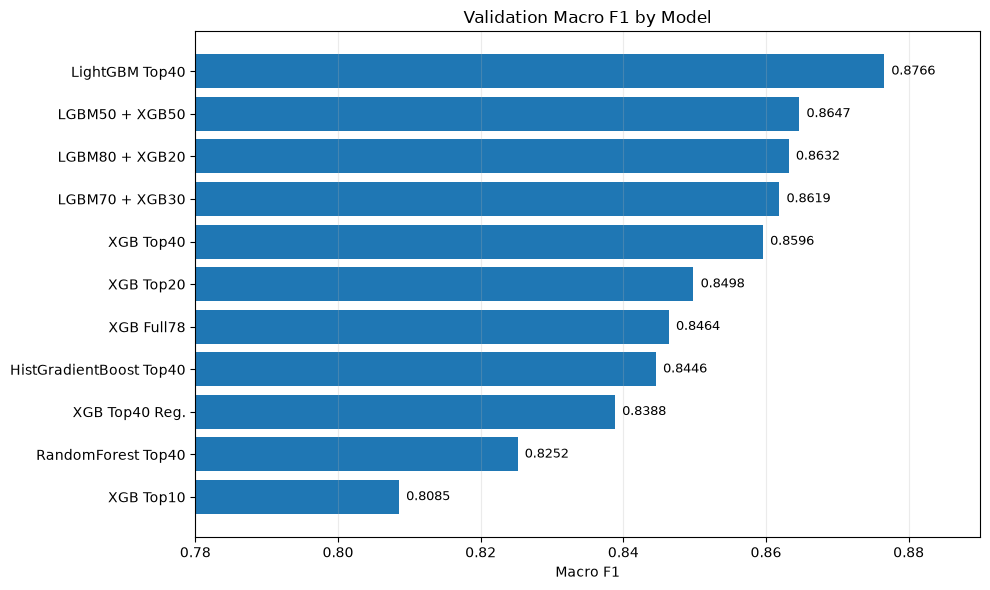

In [31]:
model_results = pd.DataFrame({
    "model": [
        "XGB Full78",
        "XGB Top40",
        "XGB Top20",
        "XGB Top10",
        "XGB Top40 Reg.",
        "RandomForest Top40",
        "HistGradientBoost Top40",
        "LightGBM Top40",
        "LGBM50 + XGB50",
        "LGBM70 + XGB30",
        "LGBM80 + XGB20",
    ],

    "macro_f1": [
        0.846377,
        0.859573,
        0.849831,
        0.808544,
        0.838829,
        0.825171,
        0.844567,
        0.876563,
        0.864666,
        0.861869,
        0.863183,
    ],
})


model_results = (
    model_results
    .sort_values("macro_f1")
    .reset_index(drop=True)
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.barh(
    model_results["model"],
    model_results["macro_f1"],
)

ax.set_title(
    "Validation Macro F1 by Model"
)

ax.set_xlabel(
    "Macro F1"
)

ax.set_xlim(
    0.78,
    0.89
)

ax.grid(
    axis="x",
    alpha=0.25
)


for bar, value in zip(
    bars,
    model_results["macro_f1"]
):
    ax.text(
        value + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center",
        fontsize=9,
    )


plt.tight_layout()

plt.savefig(
    FIG_DIR / "01_model_macro_f1_comparison.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

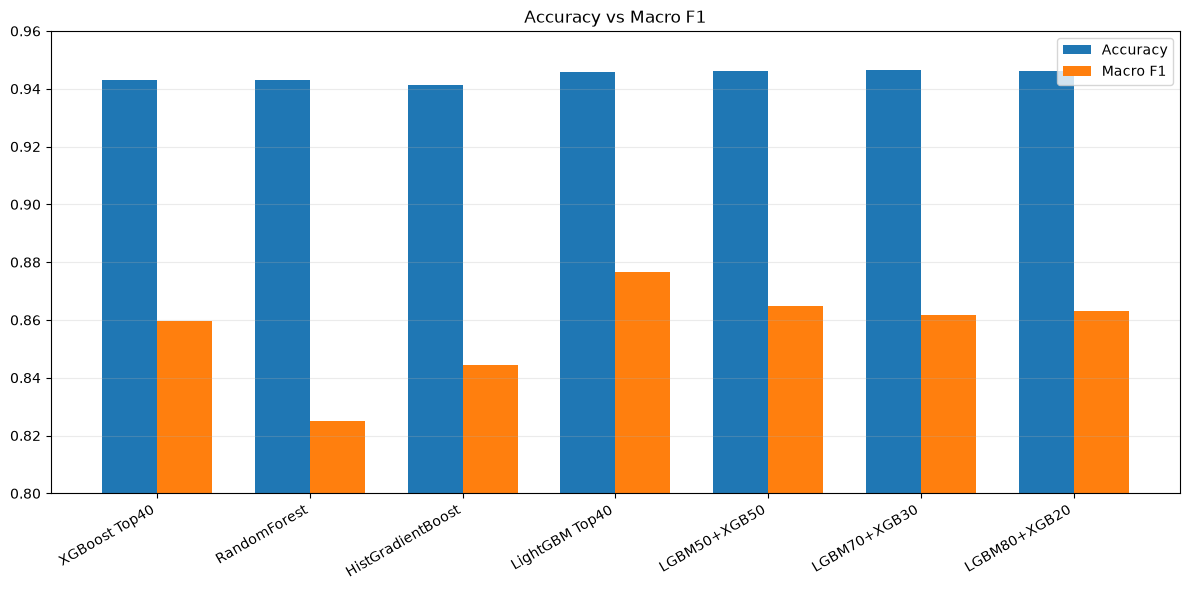

In [32]:
comparison = pd.DataFrame({
    "model": [
        "XGBoost Top40",
        "RandomForest",
        "HistGradientBoost",
        "LightGBM Top40",
        "LGBM50+XGB50",
        "LGBM70+XGB30",
        "LGBM80+XGB20",
    ],

    "accuracy": [
        0.943117,
        0.942991,
        0.941294,
        0.945792,
        0.946095,
        0.946453,
        0.946256,
    ],

    "macro_f1": [
        0.859573,
        0.825171,
        0.844567,
        0.876563,
        0.864666,
        0.861869,
        0.863183,
    ],
})


x = np.arange(
    len(comparison)
)

width = 0.36


fig, ax = plt.subplots(
    figsize=(12, 6)
)


bars1 = ax.bar(
    x - width / 2,
    comparison["accuracy"],
    width,
    label="Accuracy",
)

bars2 = ax.bar(
    x + width / 2,
    comparison["macro_f1"],
    width,
    label="Macro F1",
)


ax.set_xticks(x)

ax.set_xticklabels(
    comparison["model"],
    rotation=30,
    ha="right",
)

ax.set_ylim(
    0.80,
    0.96
)

ax.set_title(
    "Accuracy vs Macro F1"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()

plt.savefig(
    FIG_DIR / "02_accuracy_vs_macro_f1.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

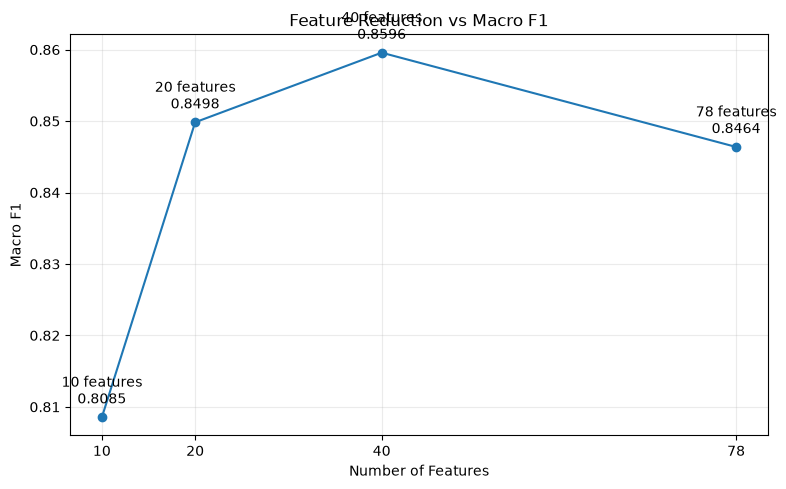

In [33]:
feature_reduction = pd.DataFrame({
    "features": [
        78,
        40,
        20,
        10,
    ],

    "macro_f1": [
        0.846377,
        0.859573,
        0.849831,
        0.808544,
    ],
})


fig, ax = plt.subplots(
    figsize=(8, 5)
)


ax.plot(
    feature_reduction["features"],
    feature_reduction["macro_f1"],
    marker="o",
)


for _, row in feature_reduction.iterrows():

    ax.annotate(
        f'{int(row["features"])} features\n'
        f'{row["macro_f1"]:.4f}',

        (
            row["features"],
            row["macro_f1"],
        ),

        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
    )


ax.set_title(
    "Feature Reduction vs Macro F1"
)

ax.set_xlabel(
    "Number of Features"
)

ax.set_ylabel(
    "Macro F1"
)

ax.set_xticks(
    [10, 20, 40, 78]
)

ax.grid(
    alpha=0.25
)


plt.tight_layout()

plt.savefig(
    FIG_DIR / "03_feature_reduction.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

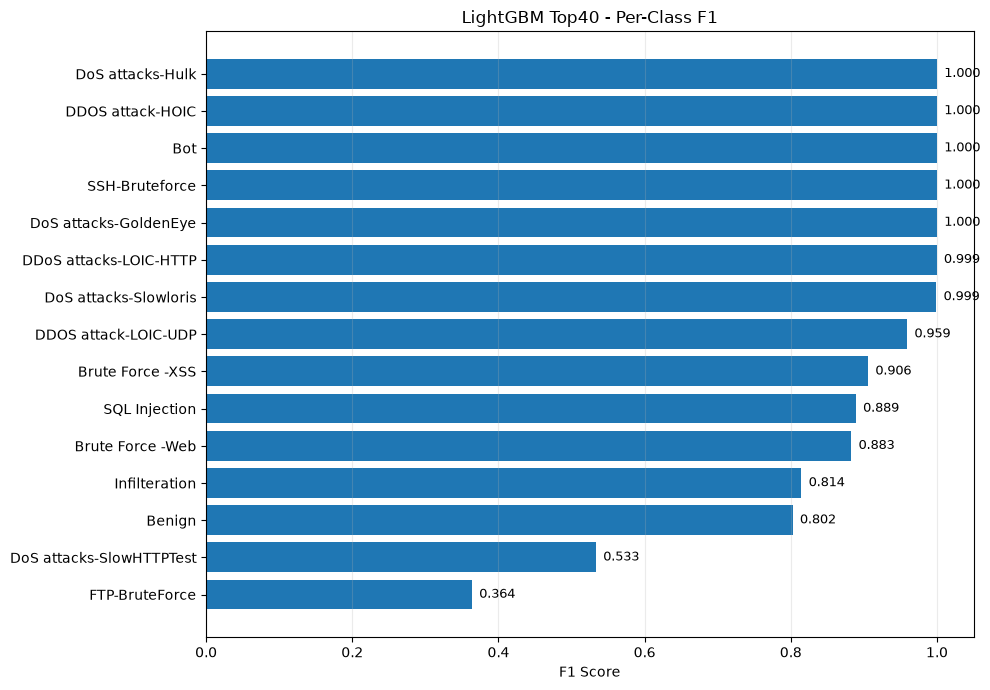

In [34]:
LGBM_REPORT_PATH = (
    RESULT_ROOT
    / "lightgbm_top40_v3"
    / "classification_report.csv"
)


report = pd.read_csv(
    LGBM_REPORT_PATH,
    index_col=0,
)


class_names = [
    "Benign",
    "Bot",
    "Brute Force -Web",
    "Brute Force -XSS",
    "DDOS attack-HOIC",
    "DDOS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-GoldenEye",
    "DoS attacks-Hulk",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-Slowloris",
    "FTP-BruteForce",
    "Infilteration",
    "SQL Injection",
    "SSH-Bruteforce",
]


class_f1 = (
    report
    .loc[class_names, ["f1-score", "support"]]
    .sort_values("f1-score")
)


fig, ax = plt.subplots(
    figsize=(10, 7)
)


bars = ax.barh(
    class_f1.index,
    class_f1["f1-score"],
)


ax.set_xlim(
    0,
    1.05
)

ax.set_title(
    "LightGBM Top40 - Per-Class F1"
)

ax.set_xlabel(
    "F1 Score"
)

ax.grid(
    axis="x",
    alpha=0.25
)


for bar, value in zip(
    bars,
    class_f1["f1-score"]
):

    ax.text(
        value + 0.01,
        bar.get_y()
        + bar.get_height() / 2,

        f"{value:.3f}",

        va="center",
        fontsize=9,
    )


plt.tight_layout()

plt.savefig(
    FIG_DIR / "04_lightgbm_per_class_f1.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

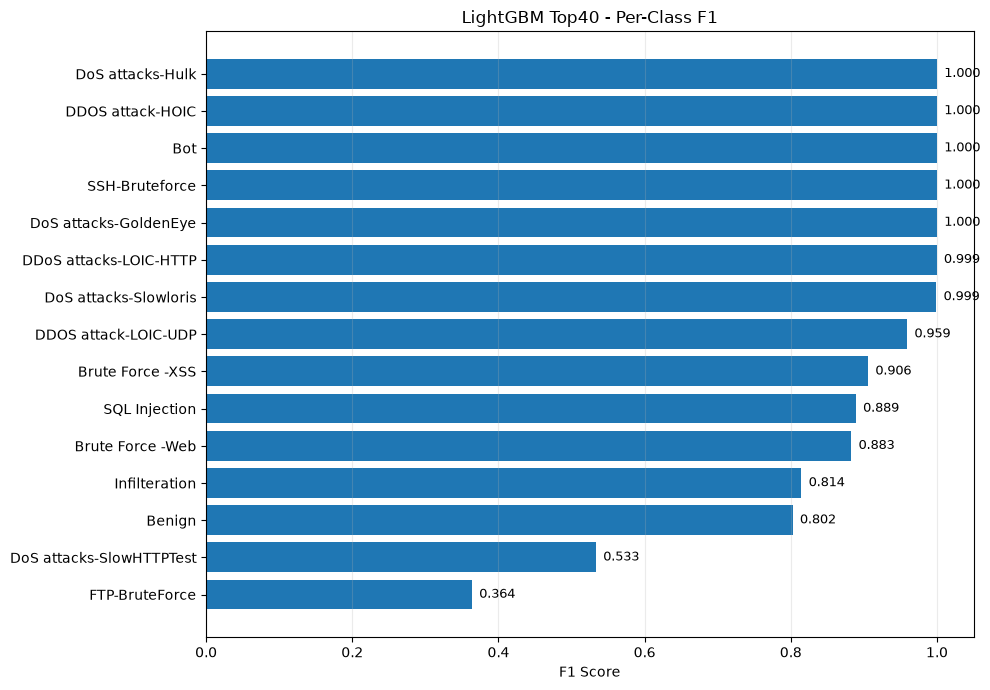

In [35]:
LGBM_REPORT_PATH = (
    RESULT_ROOT
    / "lightgbm_top40_v3"
    / "classification_report.csv"
)


report = pd.read_csv(
    LGBM_REPORT_PATH,
    index_col=0,
)


class_names = [
    "Benign",
    "Bot",
    "Brute Force -Web",
    "Brute Force -XSS",
    "DDOS attack-HOIC",
    "DDOS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-GoldenEye",
    "DoS attacks-Hulk",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-Slowloris",
    "FTP-BruteForce",
    "Infilteration",
    "SQL Injection",
    "SSH-Bruteforce",
]


class_f1 = (
    report
    .loc[class_names, ["f1-score", "support"]]
    .sort_values("f1-score")
)


fig, ax = plt.subplots(
    figsize=(10, 7)
)


bars = ax.barh(
    class_f1.index,
    class_f1["f1-score"],
)


ax.set_xlim(
    0,
    1.05
)

ax.set_title(
    "LightGBM Top40 - Per-Class F1"
)

ax.set_xlabel(
    "F1 Score"
)

ax.grid(
    axis="x",
    alpha=0.25
)


for bar, value in zip(
    bars,
    class_f1["f1-score"]
):

    ax.text(
        value + 0.01,
        bar.get_y()
        + bar.get_height() / 2,

        f"{value:.3f}",

        va="center",
        fontsize=9,
    )


plt.tight_layout()

plt.savefig(
    FIG_DIR / "04_lightgbm_per_class_f1.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

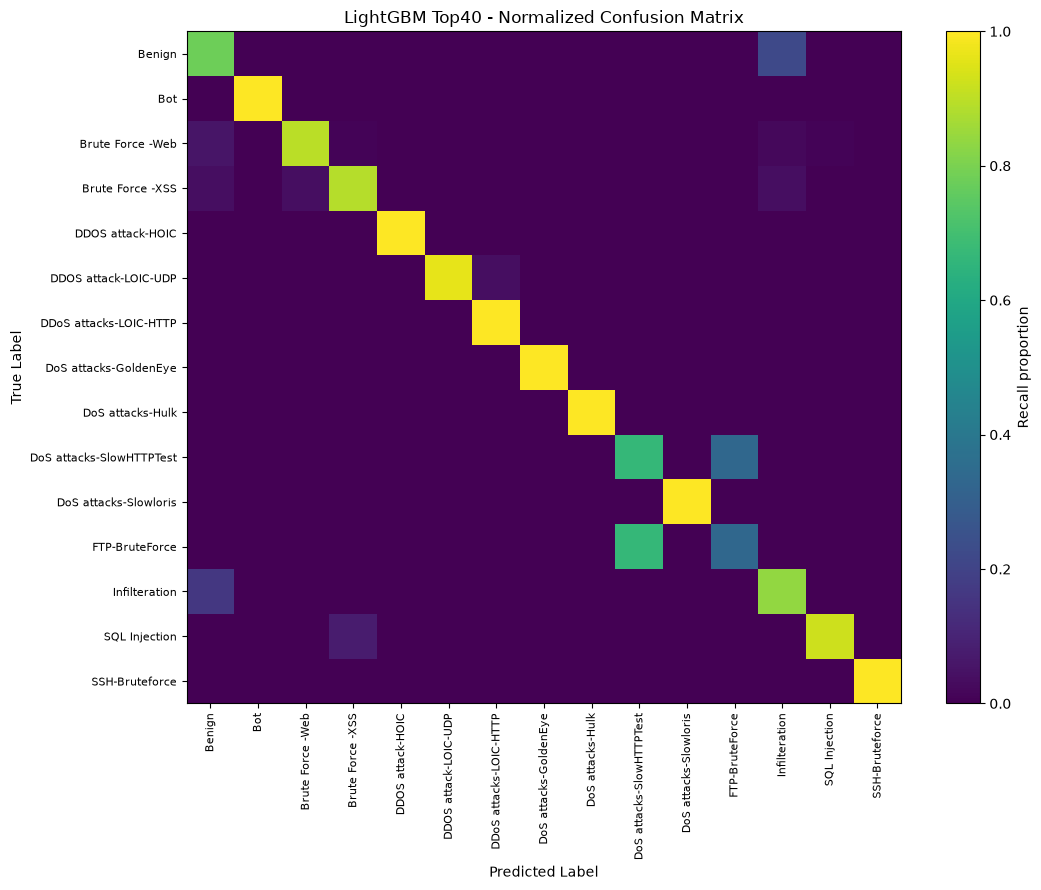

In [36]:
CM_PATH = (
    RESULT_ROOT
    / "lightgbm_top40_v3"
    / "confusion_matrix.csv"
)


cm_df = pd.read_csv(
    CM_PATH,
    index_col=0,
)


cm = cm_df.to_numpy(
    dtype=np.float64
)


row_sum = cm.sum(
    axis=1,
    keepdims=True
)


cm_normalized = np.divide(
    cm,
    row_sum,
    out=np.zeros_like(cm),
    where=row_sum != 0,
)


fig, ax = plt.subplots(
    figsize=(11, 9)
)


im = ax.imshow(
    cm_normalized,
    aspect="auto",
    vmin=0,
    vmax=1,
)


ax.set_xticks(
    np.arange(len(cm_df.columns))
)

ax.set_yticks(
    np.arange(len(cm_df.index))
)


ax.set_xticklabels(
    cm_df.columns,
    rotation=90,
    fontsize=8,
)

ax.set_yticklabels(
    cm_df.index,
    fontsize=8,
)


ax.set_xlabel(
    "Predicted Label"
)

ax.set_ylabel(
    "True Label"
)

ax.set_title(
    "LightGBM Top40 - Normalized Confusion Matrix"
)


fig.colorbar(
    im,
    ax=ax,
    label="Recall proportion",
)


plt.tight_layout()

plt.savefig(
    FIG_DIR / "05_lightgbm_confusion_matrix.png",
    dpi=220,
    bbox_inches="tight",
)

plt.show()

In [37]:
AGREEMENT_PATH = (
    RESULT_ROOT
    / "ensemble_analysis_v3"
    / "xgb_lgbm_agreement.csv"
)


agreement = pd.read_csv(
    AGREEMENT_PATH
)


print(
    agreement.to_string(
        index=False
    )
)

             category  count    ratio
         Both correct 132908 0.935432
 XGBoost only correct   1092 0.007686
LightGBM only correct   1472 0.010360
           Both wrong   6610 0.046522


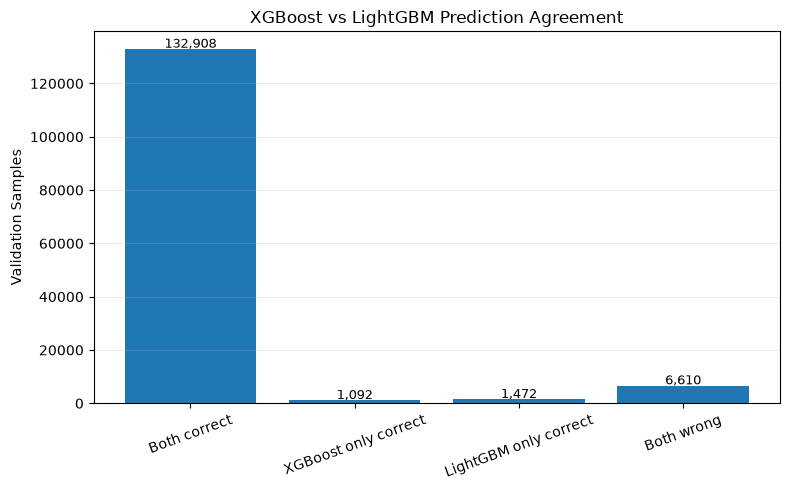

In [38]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)


bars = ax.bar(
    agreement["category"],
    agreement["count"],
)


ax.set_title(
    "XGBoost vs LightGBM Prediction Agreement"
)

ax.set_ylabel(
    "Validation Samples"
)

ax.tick_params(
    axis="x",
    rotation=20
)

ax.grid(
    axis="y",
    alpha=0.25
)


for bar, value in zip(
    bars,
    agreement["count"]
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        value + 500,

        f"{int(value):,}",

        ha="center",
        fontsize=9,
    )


plt.tight_layout()

plt.savefig(
    FIG_DIR / "06_xgb_lgbm_agreement.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

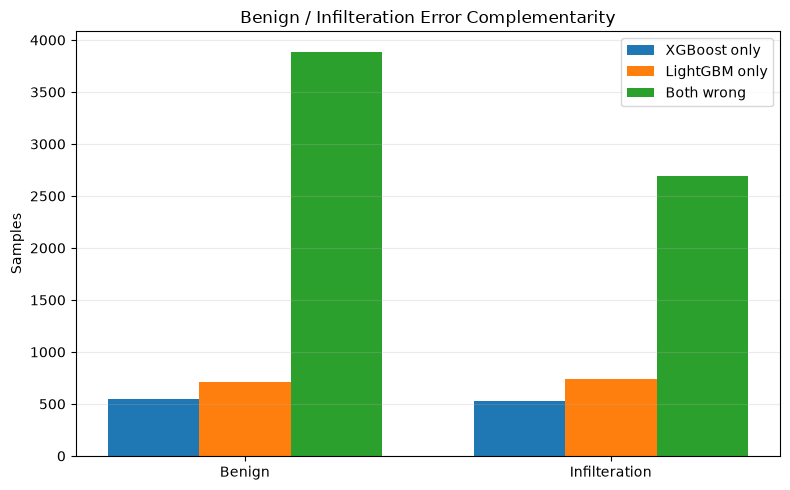

In [40]:
DISAGREEMENT_PATH = (
    RESULT_ROOT
    / "ensemble_analysis_v3"
    / "xgb_lgbm_disagreement_by_class.csv"
)


disagreement = pd.read_csv(
    DISAGREEMENT_PATH
)


focus = (
    disagreement[
        disagreement["class"].isin([
            "Benign",
            "Infilteration",
        ])
    ]
    .copy()
)


x = np.arange(
    len(focus)
)

width = 0.25


fig, ax = plt.subplots(
    figsize=(8, 5)
)


ax.bar(
    x - width,
    focus["xgb_only_correct"],
    width,
    label="XGBoost only",
)

ax.bar(
    x,
    focus["lgbm_only_correct"],
    width,
    label="LightGBM only",
)

ax.bar(
    x + width,
    focus["both_wrong"],
    width,
    label="Both wrong",
)


ax.set_xticks(x)

ax.set_xticklabels(
    focus["class"]
)


ax.set_ylabel(
    "Samples"
)

ax.set_title(
    "Benign / Infilteration Error Complementarity"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()

plt.savefig(
    FIG_DIR / "07_benign_infilteration_errors.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [41]:
print("\n=== Generated Figures ===")

for path in sorted(
    FIG_DIR.glob("*.png")
):
    print(
        path.name,
        f"{path.stat().st_size / 1024:.1f} KB"
    )


=== Generated Figures ===
01_model_macro_f1_comparison.png 114.4 KB
02_accuracy_vs_macro_f1.png 97.9 KB
03_feature_reduction.png 95.2 KB
04_lightgbm_per_class_f1.png 127.2 KB
05_lightgbm_confusion_matrix.png 199.7 KB
06_xgb_lgbm_agreement.png 75.6 KB
07_benign_infilteration_errors.png 53.5 KB
